# 15. Natural Language Processing: Pretraining

Humans need to communicate. Out of this basic need of the human condition, a vast amount of written text has been generated on an everyday basis. Given rich text in social media, chat apps, emails, product reviews, news articles, research papers, and books, it becomes vital to enable computers to understand them to offer assistance or make decisions based on human languages.

*Natural language processing* studies interactions between computers and humans using natural languages. In practice, it is very common to use natural language processing techniques to process and analyze text (human natural language) data, such as language models in Section 9.3 and machine translation models in Section 10.5.

To understand text, we can begin by learning its representations. Leveraging the existing text sequences from large corpora, *self-supervised learning* has been extensively used to pretrain text representations, such as by predicting some hidden part of the text using some other part of their surrounding text. In this way, models learn through supervision from *massive* text data without *expensive* labeling efforts!

As we will see in this chapter, when treating each word or subword as an individual token, the representation of each token can be pretrained using word2vec, GloVe, or subword embedding models on large corpora. After pretraining, representation of each token can be a vector, however, it remains the same no matter what the context is. For instance, the vector representation of “bank” is the same in both “go to the bank to deposit some money” and “go to the bank to sit down”. Thus, many more recent pretraining models adapt representation of the same token to different contexts. Among them is BERT, a much deeper self-supervised model based on the Transformer encoder. In this chapter, we will focus on how to pretrain such representations for text, as highlighted in Fig. 15.1.

![](https://d2l.ai/_images/nlp-map-pretrain.svg)
<center>Fig. 15.1 Pretrained text representations can be fed to various deep learning architectures for different downstream natural language processing applications. This chapter focuses on the upstream text representation pretraining.</center>

For sight of the big picture, Fig. 15.1 shows that the pretrained text representations can be fed to a variety of deep learning architectures for different downstream natural language processing applications. We will cover them in Section 16.

## 15.1. Word Embedding (word2vec)

Natural language is a complex system used to express meanings. In this system, words are the basic unit of the meaning. As the name implies, *word vectors* are vectors used to represent words, and can also be considered as feature vectors or representations of words. The technique of mapping words to real vectors is called *word embedding*. In recent years, word embedding has gradually become the basic knowledge of natural language processing.

### 15.1.1. One-Hot Vectors Are a Bad Choice

Although one-hot word vectors are easy to construct, they are usually not a good choice. A main reason is that one-hot word vectors cannot accurately express the similarity between different words, such as the *cosine similarity* that we often use. For vectors $\mathbf{x}, \mathbf{y} \in \mathbb{R}^d$, their cosine similarity is the cosine of the angle between them:

$$\frac{\mathbf{x}^\top \mathbf{y}}{\|\mathbf{x}\| \|\mathbf{y}\|} \in [-1, 1]. \tag{15.1.1}$$

Since the cosine similarity between one-hot vectors of any two different words is 0, one-hot vectors cannot encode similarities among words.

### 15.1.2. Self-Supervised word2vec

The word2vec tool was proposed to address the above issue. It maps each word to a fixed-length vector, and these vectors can better express the similarity and analogy relationship among different words. The word2vec tool contains two models, namely *skip-gram* (Mikolov et al., 2013) and *continuous bag of words* (CBOW) (Mikolov et al., 2013). For semantically meaningful representations, their training relies on conditional probabilities that can be viewed as predicting some words using some of their surrounding words in corpora. Since supervision comes from the data without labels, both skip-gram and continuous bag of words are self-supervised models.

In the following, we will introduce these two models and their training methods.

### 15.1.3. The Skip-Gram Model

The *skip-gram* model assumes that a word can be used to generate its surrounding words in a text sequence. Take the text sequence "the", "man", "loves", "his", "son" as an example. Let's choose "loves" as the **center word** and set the context window size to 2. As shown in Fig. 15.1.1, given the center word "loves", the skip-gram model considers the conditional probability for generating the **context words**: "the", "man", "his", and "son", which are no more than 2 words away from the center word:

$$P(\textrm{"the"},\textrm{"man"},\textrm{"his"},\textrm{"son"}\mid\textrm{"loves"}). \tag{15.1.2}$$

Assume that the context words are independently generated given the center word (i.e., conditional independence). In this case, the above conditional probability can be rewritten as

$$P(\textrm{"the"}\mid\textrm{"loves"})\cdot P(\textrm{"man"}\mid\textrm{"loves"})\cdot P(\textrm{"his"}\mid\textrm{"loves"})\cdot P(\textrm{"son"}\mid\textrm{"loves"}). \tag{15.1.3}$$

![](https://d2l.ai/_images/skip-gram.svg)
<center>Fig. 15.1.1 The skip-gram model considers the conditional probability of generating the surrounding context words given a center word.</center>

In the skip-gram model, each word has two $d$-dimensional-vector representations for calculating conditional probabilities. More concretely, for any word with index $i$ in the dictionary, denote by $\mathbf{v}_i\in\mathbb{R}^d$ and $\mathbf{u}_i\in\mathbb{R}^d$ its two vectors when used as a *center* word and a *context* word, respectively. The conditional probability of generating any context word $w_o$ (with index $o$ in the dictionary) given the center word $w_c$ (with index $c$ in the dictionary) can be modeled by a softmax operation on vector dot products:

$$P(w_o \mid w_c) = \frac{\exp(\mathbf{u}_o^\top \mathbf{v}_c)}{ \sum_{i \in \mathcal{V}} \exp(\mathbf{u}_i^\top \mathbf{v}_c)}, \tag{15.1.4}$$

where the vocabulary index set $\mathcal{V} = \{0, 1, \ldots, |\mathcal{V}|-1\}$. Given a text sequence of length $T$, where the word at time step $t$ is denoted as $w^{(t)}$. Assume that context words are independently generated given any center word. For context window size $m$, the likelihood function of the skip-gram model is the probability of generating all context words given any center word:

$$ \prod_{t=1}^{T} \prod_{-m \leq j \leq m,\ j \neq 0} P(w^{(t+j)} \mid w^{(t)}), \tag{15.1.5}$$

where any time step that is less than $1$ or greater than $T$ can be omitted.

---
牧之：文字是有顺序的，这个独立的假设是不是有点问题啊？

通义：确实，您提出了一点很关键的观察。在自然语言处理中，文本序列中的单词之间往往存在很强的依赖关系和顺序性。跳元模型中关于条件独立性的假设主要是为了简化计算，它假设给定中心词的情况下，上下文词之间是相互独立生成的。这一假设简化了模型的复杂度，允许我们更容易地学习到词之间的共现关系，但的确可能忽略了语言中固有的顺序信息和依赖关系。

具体到公式 (15.1.3)，它表明在 "loves" 出现的条件下，"the"、"man"、"his" 和 "son" 每个词的生成概率是互不影响的。然而，在实际语言中，"the man loves his son" 这样的序列暗示了词语之间存在很强的依赖关系和语境意义，例如 "man" 和 "his" 之间、 “loves” 和 “son” 之间的关联是高度相关的，不应该视为完全独立。

尽管如此，跳元模型及其简化假设在实践中仍然非常有效，尤其是在捕捉全局共现模式和学习高质量词嵌入方面。它通过大量的文本数据学习到的词向量能够编码许多关于词汇用法和上下文的信息，尽管可能不足以精确捕捉所有细微的语言结构和依赖性。对于更复杂的语言结构和顺序依赖，可能需要采用如 RNNs、LSTMs、Transformers 等更先进的模型，这些模型能更好地建模序列数据中的时序和依赖关系。

---
牧之：参考 Fig. 15.1，这个条件独立假设可能也不是大问题，序列属性会在架构层被关注和解决。

### 15.1.3.1. Training

The skip-gram model parameters are the center word vector and context word vector for each word in the vocabulary. In training, we learn the model parameters by maximizing the likelihood function (i.e., maximum likelihood estimation). This is equivalent to minimizing the following loss function:

$$ - \sum_{t=1}^{T} \sum_{-m \leq j \leq m,\ j \neq 0} \textrm{log}\, P(w^{(t+j)} \mid w^{(t)}). \tag{15.1.6}$$

When using stochastic gradient descent to minimize the loss, in each iteration we can randomly sample a shorter subsequence to calculate the (stochastic) gradient for this subsequence to update the model parameters. To calculate this (stochastic) gradient, we need to obtain the gradients of the log conditional probability with respect to the center word vector and the context word vector. In general, according to (15.1.4) the log conditional probability involving any pair of the center word $w_c$ and the context word $w_o$ is

$$\log P(w_o \mid w_c) =\mathbf{u}_o^\top \mathbf{v}_c - \log\left(\sum_{i \in \mathcal{V}} \exp(\mathbf{u}_i^\top \mathbf{v}_c)\right). \tag{15.1.7}$$

Through differentiation, we can obtain its gradient with respect to the center word vector $\mathbf{v}_c$ as

$$\begin{aligned}\frac{\partial \textrm{log}\, P(w_o \mid w_c)}{\partial \mathbf{v}_c}&= \mathbf{u}_o - \frac{\sum_{j \in \mathcal{V}} \exp(\mathbf{u}_j^\top \mathbf{v}_c)\mathbf{u}_j}{\sum_{i \in \mathcal{V}} \exp(\mathbf{u}_i^\top \mathbf{v}_c)}\\&= \mathbf{u}_o - \sum_{j \in \mathcal{V}} \left(\frac{\exp(\mathbf{u}_j^\top \mathbf{v}_c)}{ \sum_{i \in \mathcal{V}} \exp(\mathbf{u}_i^\top \mathbf{v}_c)}\right) \mathbf{u}_j\\&= \mathbf{u}_o - \sum_{j \in \mathcal{V}} P(w_j \mid w_c) \mathbf{u}_j.\end{aligned} \tag{15.1.8}$$

Note that the calculation in (15.1.8) requires the conditional probabilities of all words in the dictionary with $w_c$ as the center word. The gradients for the other word vectors can be obtained in the same way.

After training, for any word with index $i$ in the dictionary, we obtain both word vectors $\mathbf{v}_i$ (as the center word) and $\mathbf{u}_i$ (as the context word). In natural language processing applications, the center word vectors of the skip-gram model are typically used as the word representations.

### 15.1.4. The Continuous Bag of Words (CBOW) Model

The *continuous bag of words* (CBOW) model is similar to the skip-gram model. The major difference from the skip-gram model is that the continuous bag of words model assumes that a center word is generated based on its surrounding context words in the text sequence. For example, in the same text sequence “the”, “man”, “loves”, “his”, and “son”, with “loves” as the center word and the context window size being 2, the continuous bag of words model considers the conditional probability of generating the center word “loves” based on the context words “the”, “man”, “his” and “son” (as shown in Fig. 15.1.2), which is

$$P(\textrm{"loves"}\mid\textrm{"the"},\textrm{"man"},\textrm{"his"},\textrm{"son"}). \tag{15.1.9}$$

![](http://d2l.ai/_images/cbow.svg)
<center>Fig. 15.1.2 The continuous bag of words model considers the conditional probability of generating the center word given its surrounding context words.</center>

Since there are multiple context words in the continuous bag of words model, these context word vectors are averaged in the calculation of the conditional probability. Specifically, for any word with index $i$ in the dictionary, denote by $\mathbf{v}_i\in\mathbb{R}^d$ and $\mathbf{u}_i\in\mathbb{R}^d$ its two vectors when used as a *context* word and a *center* word (meanings are switched in the skip-gram model), respectively. The conditional probability of generating any center word $w_c$ (with index $c$ in the dictionary) given its surrounding context words $w_{o_1}, \ldots, w_{o_{2m}}$ (with index $o_1, \ldots, o_{2m}$ in the dictionary) can be modeled by

$$P(w_c \mid w_{o_1}, \ldots, w_{o_{2m}}) = \frac{\exp\left(\frac{1}{2m}\mathbf{u}_c^\top (\mathbf{v}_{o_1} + \ldots + \mathbf{v}_{o_{2m}}) \right)}{ \sum_{i \in \mathcal{V}} \exp\left(\frac{1}{2m}\mathbf{u}_i^\top (\mathbf{v}_{o_1} + \ldots + \mathbf{v}_{o_{2m}}) \right)}. \tag{15.1.10}$$

For brevity, let $\mathcal{W}_o= \{w_{o_1}, \ldots, w_{o_{2m}}\}$ and $\bar{\mathbf{v}}_o = \left(\mathbf{v}_{o_1} + \ldots + \mathbf{v}_{o_{2m}} \right)/(2m)$. Then (15.1.10) can be simplified as

$$P(w_c \mid \mathcal{W}_o) = \frac{\exp\left(\mathbf{u}_c^\top \bar{\mathbf{v}}_o\right)}{\sum_{i \in \mathcal{V}} \exp\left(\mathbf{u}_i^\top \bar{\mathbf{v}}_o\right)}. \tag{15.1.11}$$

Given a text sequence of length $T$, where the word at time step $t$ is denoted as $w^{(t)}$. For context window size $m$, the likelihood function of the continuous bag of words model is the probability of generating all center words given their context words:

$$ \prod_{t=1}^{T}  P(w^{(t)} \mid  w^{(t-m)}, \ldots, w^{(t-1)}, w^{(t+1)}, \ldots, w^{(t+m)}). \tag{15.1.12}$$

#### 15.1.4.1. Training

Training continuous bag of words models is almost the same as training skip-gram models. The maximum likelihood estimation of the continuous bag of words model is equivalent to minimizing the following loss function:

$$  -\sum_{t=1}^T  \textrm{log}\, P(w^{(t)} \mid  w^{(t-m)}, \ldots, w^{(t-1)}, w^{(t+1)}, \ldots, w^{(t+m)}). \tag{15.1.13}$$

Notice that

$$\log\,P(w_c \mid \mathcal{W}_o) = \mathbf{u}_c^\top \bar{\mathbf{v}}_o - \log\,\left(\sum_{i \in \mathcal{V}} \exp\left(\mathbf{u}_i^\top \bar{\mathbf{v}}_o\right)\right). \tag{15.1.14}$$

Through differentiation, we can obtain its gradient with respect to any context word vector $\mathbf{v}_{o_i}$($i = 1, \ldots, 2m$) as

$$\frac{\partial \log\, P(w_c \mid \mathcal{W}_o)}{\partial \mathbf{v}_{o_i}} = \frac{1}{2m} \left(\mathbf{u}_c - \sum_{j \in \mathcal{V}} \frac{\exp(\mathbf{u}_j^\top \bar{\mathbf{v}}_o)\mathbf{u}_j}{ \sum_{i \in \mathcal{V}} \exp(\mathbf{u}_i^\top \bar{\mathbf{v}}_o)} \right) = \frac{1}{2m}\left(\mathbf{u}_c - \sum_{j \in \mathcal{V}} P(w_j \mid \mathcal{W}_o) \mathbf{u}_j \right). \tag{15.1.15}$$

The gradients for the other word vectors can be obtained in the same way. Unlike the skip-gram model, the continuous bag of words model typically uses context word vectors as the word representations.

### 15.1.5. Summary

* Word vectors are vectors used to represent words, and can also be considered as feature vectors or representations of words. The technique of mapping words to real vectors is called word embedding.

* The word2vec tool contains both the skip-gram  and continuous bag of words models.

* The skip-gram model assumes that a word can be used to generate its surrounding words in a text sequence; while the continuous bag of words model assumes that a center word is generated based on its surrounding context words.

### 15.1.6. Exercises

1. What is the computational complexity for calculating each gradient? What could be the issue if the dictionary size is huge?

1. Some fixed phrases in English consist of multiple words, such as "new york". How to train their word vectors? Hint: see Section 4 in the word2vec paper (Mikolov et al., 2013).

1. Let's reflect on the word2vec design by taking the skip-gram model as an example. What is the relationship between the dot product of two word vectors in the skip-gram model and the cosine similarity? For a pair of words with similar semantics, why may the cosine similarity of their word vectors (trained by the skip-gram model) be high?

## 15.2. Approximate Training

Recall our discussions in Section 15.1. The main idea of the skip-gram model is using softmax operations to calculate the conditional probability of generating a context word $w_o$ based on the given center word $w_c$ in (15.1.4), whose corresponding logarithmic loss is given by the opposite of (15.1.7).

Due to the nature of the softmax operation, since a context word may be anyone in the dictionary $\mathcal{V}$, the opposite of (15.1.7) contains the summation of items as many as the entire size of the vocabulary. Consequently, the gradient calculation for the skip-gram model in (15.1.8) and that for the continuous bag-of-words model in (15.1.15) both contain the summation. Unfortunately, the computational cost for such gradients that sum over a large dictionary (often with hundreds of thousands or millions of words) is huge!

In order to reduce the aforementioned computational complexity, this section will introduce two approximate training methods: *negative sampling* and *hierarchical softmax*. Due to the similarity between the skip-gram model and the continuous bag of words model, we will just take the skip-gram model as an example to describe these two approximate training methods.

### 15.2.1. Negative Sampling

Negative sampling modifies the original objective function. Given the context window of a center word $w_c$, the fact that any (context) word $w_o$ comes from this context window is considered as an event with the probability modeled by

$$P(D=1\mid w_c, w_o) = \sigma(\mathbf{u}_o^\top \mathbf{v}_c), \tag{15.2.1}$$

where $\sigma$ uses the definition of the sigmoid activation function:

$$\sigma(x) = \frac{1}{1+\exp(-x)}. \tag{15.2.2}$$

Let's begin by maximizing the joint probability of all such events in text sequences to train word embeddings. Specifically, given a text sequence of length $T$, denote by $w^{(t)}$ the word at time step $t$ and let the context window size be $m$, consider maximizing the joint probability

$$\prod_{t=1}^{T} \prod_{-m \leq j \leq m,\ j \neq 0} P(D=1\mid w^{(t)}, w^{(t+j)}). \tag{15.2.3}$$

However, (15.2.3) only considers those events that involve positive examples. As a result, the joint probability in (15.2.3) is maximized to 1 only if all the word vectors are equal to infinity. Of course, such results are meaningless. To make the objective function more meaningful, *negative sampling* adds negative examples sampled from a predefined distribution.

Denote by $S$ the event that a context word $w_o$ comes from the context window of a center word $w_c$. For this event involving $w_o$, from a predefined distribution $P(w)$ sample $K$ *noise words* that are not from this context window. Denote by $N_k$ the event that a noise word $w_k$ ($k=1, \ldots, K$) does not come from the context window of $w_c$. Assume that these events involving both the positive example and negative examples $S, N_1, \ldots, N_K$ are mutually independent. Negative sampling rewrites the joint probability (involving only positive examples) in (15.2.3) as

$$ \prod_{t=1}^{T} \prod_{-m \leq j \leq m,\ j \neq 0} P(w^{(t+j)} \mid w^{(t)}), \tag{15.2.4}$$

where the conditional probability is approximated through events $S, N_1, \ldots, N_K$:

$$P(w^{(t+j)} \mid w^{(t)}) =P(D=1\mid w^{(t)}, w^{(t+j)})\prod_{k=1,\ w_k \sim P(w)}^K P(D=0\mid w^{(t)}, w_k). \tag{15.2.5}$$

Denote by $i_t$ and $h_k$ the indices of a word $w^{(t)}$ at time step $t$ of a text sequence and a noise word $w_k$, respectively. The logarithmic loss with respect to the conditional probabilities in (15.2.5) is

$$ \begin{aligned} -\log P(w^{(t+j)} \mid w^{(t)}) =& -\log P(D=1\mid w^{(t)}, w^{(t+j)}) - \sum_{k=1,\ w_k \sim P(w)}^K \log P(D=0\mid w^{(t)}, w_k)\\ =&-  \log\, \sigma\left(\mathbf{u}_{i_{t+j}}^\top \mathbf{v}_{i_t}\right) - \sum_{k=1,\ w_k \sim P(w)}^K \log\left(1-\sigma\left(\mathbf{u}_{h_k}^\top \mathbf{v}_{i_t}\right)\right)\\ =&-  \log\, \sigma\left(\mathbf{u}_{i_{t+j}}^\top \mathbf{v}_{i_t}\right) - \sum_{k=1,\ w_k \sim P(w)}^K \log\sigma\left(-\mathbf{u}_{h_k}^\top \mathbf{v}_{i_t}\right). \end{aligned} \tag{15.2.6}$$

We can see that now the computational cost for gradients at each training step has nothing to do with the dictionary size, but linearly depends on $K$. When setting the hyperparameter $K$ to a smaller value, the computational cost for gradients at each training step with negative sampling is smaller.

---
牧之：这是因为如果希望两个向量的内积要无限大，那么向量的范数也要无限大。

> As a result, the joint probability in (15.2.3) is maximized to 1 only if all the word vectors are equal to infinity.

---
牧之：请帮忙详解一下，(15.2.3) 是如何可以成为 (15.2.4) 的？

通义：从直观上解释，(15.2.3) 和 (15.2.4) 的转换，实际上是为了引入负采样（negative sampling）的概念来改进原模型的学习目标，使其不仅考虑正例（实际共现的词对），还考虑负例（随机采样的非共现词对）。下面详细说明这一转换过程：

**从 (15.2.3) 到 (15.2.4)**

原始的目标函数（15.2.3）只关注于正例，即中心词和它真实出现在上下文窗口内的词对的概率乘积最大化。这可以表示为：

$$\prod_{t=1}^{T} \prod_{-m \leq j \leq m,\ j \neq 0} P(D=1\mid w^{(t)}, w^{(t+j)}). \tag{15.2.3}$$

其中 $D=1$ 表示正例，即两个词确实共现。

然而，(15.2.4) 形式上的变化，是通过引入一个对称的视角，不再直接显式区分正负例，而是转而考虑中心词 $w^{(t)}$ 给定下，任一词（包括正例和负例）出现的条件概率乘积，以此作为新的优化目标：

$$ \prod_{t=1}^{T} \prod_{-m \leq j \leq m,\ j \neq 0} P(w^{(t+j)} \mid w^{(t)}), \tag{15.2.4}$$

这里的关键转换在于，如何从原始的条件概率 $P(D=1\mid w^{(t)}, w^{(t+j)})$ 转换为 $P(w^{(t+j)} \mid w^{(t)})$。直观上，这个新表达形式为所有词对（无论是否共现）的条件概率提供了一个统一框架，但这背后具体的数学转换，实际上是通过引入负采样和对条件概率的重新定义来实现的，这体现在 (15.2.5) 中。

**引入负采样后的条件概率（15.2.5）**

为了结合正负例信息并避免上述提及的模型学习无意义词向量的问题，(15.2.5) 提出了一个新的条件概率计算方法，将条件概率 $P(w^{(t+j)} \mid w^{(t)})$ 分解为两部分：正例概率与多个负例概率的乘积。具体来说：

$$P(w^{(t+j)} \mid w^{(t)}) = P(D=1\mid w^{(t)}, w^{(t+j)})\prod_{k=1,\ w_k \sim P(w)}^K P(D=0\mid w^{(t)}, w_k). \tag{15.2.5}$$

这里的含义是，对于每个真正的共现对（正例）$w^{(t+j)}$ 来说，它的条件概率不仅仅取决于它自身与中心词 $w^{(t)}$ 的共现概率（$P(D=1\mid w^{(t)}, w^{(t+j)})$），还乘以了从背景分布 $P(w)$ 中随机抽取的 $K$ 个噪声词 $w_k$ 不与中心词 $w^{(t)}$共现的概率的乘积（每个噪声词的概率用 $P(D=0\mid w^{(t)}, w_k)$ 表示）。通过这种方式，模型既考虑了正例（应该被预测为共现的），又考虑了负例（不应被错误预测为共现的），实现了更全面且有意义的学习目标。

总结而言，(15.2.4) 实际上是对原始公式（15.2.3）的重新表述，旨在引入负采样机制来克服仅考虑正例带来的局限性，而 (15.2.5) 则是实现这一转换的具体数学处理方式，通过结合正负例信息来更合理地估计条件概率，从而优化词向量的训练过程。


### 15.2.2. Hierarchical Softmax

As an alternative approximate training method, *hierarchical softmax* uses the binary tree, a data structure illustrated in Fig. 15.2.1, where each leaf node of the tree represents a word in dictionary $\mathcal{V}$.

![](https://d2l.ai/_images/hi-softmax.svg)
<center>Fig. 15.2.1 Hierarchical softmax for approximate training, where each leaf node of the tree represents a word in the dictionary.</center>

Denote by $L(w)$ the number of nodes (including both ends) on the path from the root node to the leaf node representing word $w$ in the binary tree. Let $n(w,j)$ be the $j^\textrm{th}$ node on this path, with its context word vector being $\mathbf{u}_{n(w, j)}$. For example, $L(w_3) = 4$ in Fig. 15.2.1. Hierarchical softmax approximates the conditional probability in (15.1.4) as

$$P(w_o \mid w_c) = \prod_{j=1}^{L(w_o)-1} \sigma\left( [\![  n(w_o, j+1) = \textrm{leftChild}(n(w_o, j)) ]\!] \cdot \mathbf{u}_{n(w_o, j)}^\top \mathbf{v}_c\right), \tag{15.2.7}$$

where function $\sigma$ is defined in (15.2.2), and $\textrm{leftChild}(n)$ is the left child node of node $n$: if $x$ is true, $[\![x]\!] = 1$; otherwise $[\![x]\!] = -1$.

To illustrate, let's calculate the conditional probability of generating word $w_3$ given word $w_c$ in Fig. 15.2.1. This requires dot products between the word vector $\mathbf{v}_c$ of $w_c$ and non-leaf node vectors on the path (the path in bold in Fig. 15.2.1) from the root to $w_3$, which is traversed left, right, then left:

$$P(w_3 \mid w_c) = \sigma(\mathbf{u}_{n(w_3, 1)}^\top \mathbf{v}_c) \cdot \sigma(-\mathbf{u}_{n(w_3, 2)}^\top \mathbf{v}_c) \cdot \sigma(\mathbf{u}_{n(w_3, 3)}^\top \mathbf{v}_c). \tag{15.2.8}$$

Since $\sigma(x)+\sigma(-x) = 1$, it holds that the conditional probabilities of generating all the words in dictionary $\mathcal{V}$ based on any word $w_c$ sum up to one:

$$\sum_{w \in \mathcal{V}} P(w \mid w_c) = 1. \tag{15.2.9}$$

Fortunately, since $L(w_o)-1$ is on the order of $\mathcal{O}(\textrm{log}_2|\mathcal{V}|)$ due to the binary tree structure, when the dictionary size $\mathcal{V}$ is huge, the computational cost for  each training step using hierarchical softmax is significantly reduced compared with that without approximate training.

---
牧之：节点向量到底是个什么东西？

通义：节点向量（node vector）在层次Softmax的上下文中，是用于表示二叉树中非叶子节点的向量表示。这些向量是模型参数的一部分，会在训练过程中学习得到，与中心词（context word）的词向量一样，都是通过反向传播和梯度下降等优化方法更新的。

具体来说，每个非叶子节点 $n$ 都有一个关联的向量 $\mathbf{u}_{n}$。在计算给定中心词 $w_c$ 下目标词 $w_o$ 的条件概率时，层次 Softmax 通过从根节点到 $w_o$ 所在叶子节点的路径上所有内部节点的向量与中心词向量 $\mathbf{v}_c$ 进行点积运算来逐步决策。这个点积的结果反映了从当前节点到目标词路径的一个倾向性，结合路径的方向（通过符号函数指示），可以看作是在当前层级上判断“向左”还是“向右”走的概率。

简而言之，节点向量是模型用于学习和存储关于词汇间相对位置和区分信息的一种方式，它们帮助模型在树形结构中高效地导航到目标词汇，同时减小了计算复杂度。这些向量不仅编码了词汇间的上下文关系，也通过层次 Softmax 的结构化方式，间接体现了词汇的语义和统计特性。

### 15.2.3. Summary

* Negative sampling constructs the loss function by considering mutually independent events that involve both positive and negative examples. The computational cost for training is linearly dependent on the number of noise words at each step.

* Hierarchical softmax constructs the loss function using  the path from the root node to the leaf node in the binary tree. The computational cost for training is dependent on the logarithm of the dictionary size at each step.

### 15.2.4. Exercises

1. How can we sample noise words in negative sampling?

1. Verify that (15.2.9) holds.

1. How to train the continuous bag of words model using negative sampling and hierarchical softmax, respectively?

## 15.3. The Dataset for Pretraining Word Embeddings

Now that we know the technical details of the word2vec models and approximate training methods, let’s walk through their implementations. Specifically, we will take the skip-gram model in Section 15.1 and negative sampling in Section 15.2 as an example. In this section, we begin with the dataset for pretraining the word embedding model: the original format of the data will be transformed into minibatches that can be iterated over during training.

In [ ]:
import collections
import math
import os
import random
import torch
from d2l import torch as d2l

### 15.3.1. Reading the Dataset

The dataset that we use here is [Penn Tree Bank (PTB)](https://catalog.ldc.upenn.edu/LDC99T42). This corpus is sampled from Wall Street Journal articles, split into training, validation, and test sets. In the original format, each line of the text file represents a sentence of words that are separated by spaces. Here we treat each word as a token.

In [ ]:
#@ save
d2l.DATA_HUB['ptb'] = (d2l.DATA_URL + 'ptb.zip',
                       '319d85e578af0cdc590547f26231e4e31cdf1e42')

#@ save
def read_ptb():
    """Load the PTB dataset into a list of text lines."""
    data_dir = d2l.download_extract('ptb')
    # Read the training set
    with open(os.path.join(data_dir, 'ptb.train.txt')) as f:
        raw_text = f.read()
    return [line.split() for line in raw_text.split('\n')]

sentences = read_ptb()
f'# sentences: {len(sentences)}'

'# sentences: 42069'

After reading the training set, we build a vocabulary for the corpus, where any word that appears less than 10 times is replaced by the "&lt;unk&gt;" token. Note that the original dataset also contains "&lt;unk&gt;" tokens that represent rare (unknown) words.

In [ ]:
vocab = d2l.Vocab(sentences, min_freq=10)
f'vocab size: {len(vocab)}'

'vocab size: 6719'

### 15.3.2. Subsampling

Text data typically have high-frequency words such as "the", "a", and "in": they may even occur billions of times in very large corpora. However, these words often co-occur with many different words in context windows, providing little useful signals. For instance, consider the word "chip" in a context window: intuitively its co-occurrence with a low-frequency word "intel" is more useful in training than the co-occurrence with a high-frequency word "a". Moreover, training with vast amounts of (high-frequency) words is slow. Thus, when training word embedding models, high-frequency words can be *subsampled* (Mikolov et al., 2013). Specifically, each indexed word $w_i$ in the dataset will be discarded with probability

$$ P(w_i) = \max\left(1 - \sqrt{\frac{t}{f(w_i)}}, 0\right), \tag{15.3.1}$$

where $f(w_i)$ is the ratio of the number of words $w_i$ to the total number of words in the dataset, and the constant $t$ is a hyperparameter ($10^{-4}$ in the experiment). We can see that only when the relative frequency $f(w_i) > t$  can the (high-frequency) word $w_i$ be discarded, and the higher the relative frequency of the word, the greater the probability of being discarded.

In [ ]:
#@ save
def subsample(sentences, vocab):
    """Subsample high-frequency words."""
    # Exclude unknown tokens ('<unk>')
    sentences = [[token for token in line if vocab[token] != vocab.unk]
                 for line in sentences]
    counter = collections.Counter([
        token for line in sentences for token in line])
    num_tokens = sum(counter.values())

    # Return True if `token` is kept during subsampling
    def keep(token):
        return(random.uniform(0, 1) <
               math.sqrt(1e-4 / counter[token] * num_tokens))

    return ([[token for token in line if keep(token)] for line in sentences],
            counter)

subsampled, counter = subsample(sentences, vocab)

The following code snippet plots the histogram of the number of tokens per sentence before and after subsampling. As expected, subsampling significantly shortens sentences by dropping high-frequency words, which will lead to training speedup.

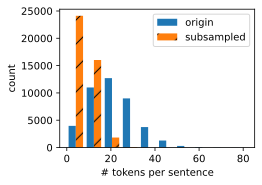

In [ ]:
d2l.show_list_len_pair_hist(['origin', 'subsampled'], '# tokens per sentence',
                            'count', sentences, subsampled);

For individual tokens, the sampling rate of the high-frequency word “the” is less than 1/20.

In [ ]:
def compare_counts(token):
    return (f'# of "{token}": '
            f'before={sum([l.count(token) for l in sentences])}, '
            f'after={sum([l.count(token) for l in subsampled])}')

compare_counts('the')

'# of "the": before=50770, after=2054'

In contrast, low-frequency words “join” are completely kept.

In [ ]:
compare_counts('join')

'# of "join": before=45, after=45'

After subsampling, we map tokens to their indices for the corpus.

In [ ]:
corpus = [vocab[line] for line in subsampled]
corpus[:3]

[[], [4127, 3228, 4060], [993, 3922, 1922, 4743, 2696]]

### 15.3.3. Extracting Center Words and Context Words

The following `get_centers_and_contexts` function extracts all the center words and their context words from `corpus`. It uniformly samples an integer between 1 and `max_window_size` at random as the context window size. For any center word, those words whose distance from it does not exceed the sampled context window size are its context words.

In [ ]:
#@ save
def get_centers_and_contexts(corpus, max_window_size):
    """Return center words and context words in skip-gram."""
    centers, contexts = [], []
    for line in corpus:
        # To form a "center word--context word" pair, each sentence needs to
        # have at least 2 words
        if len(line) < 2:
            continue
        centers += line
        for i in range(len(line)):  # Context window centered at `i`
            window_size = random.randint(1, max_window_size)
            indices = list(range(max(0, i - window_size),
                                 min(len(line), i + 1 + window_size)))
            # Exclude the center word from the context words
            indices.remove(i)
            contexts.append([line[idx] for idx in indices])
    return centers, contexts

Next, we create an artificial dataset containing two sentences of 7 and 3 words, respectively. Let the maximum context window size be 2 and print all the center words and their context words.

In [ ]:
tiny_dataset = [list(range(7)), list(range(7, 10))]
print('dataset', tiny_dataset)
for center, context in zip(*get_centers_and_contexts(tiny_dataset, 2)):
    print('center', center, 'has contexts', context)

dataset [[0, 1, 2, 3, 4, 5, 6], [7, 8, 9]]
center 0 has contexts [1]
center 1 has contexts [0, 2]
center 2 has contexts [1, 3]
center 3 has contexts [2, 4]
center 4 has contexts [2, 3, 5, 6]
center 5 has contexts [4, 6]
center 6 has contexts [5]
center 7 has contexts [8]
center 8 has contexts [7, 9]
center 9 has contexts [7, 8]


When training on the PTB dataset, we set the maximum context window size to 5. The following extracts all the center words and their context words in the dataset.

In [ ]:
all_centers, all_contexts = get_centers_and_contexts(corpus, 5)
f'# center-context pairs: {sum([len(contexts) for contexts in all_contexts])}'

'# center-context pairs: 1503223'

### 15.3.4. Negative Sampling

We use negative sampling for approximate training. To sample noise words according to a predefined distribution, we define the following `RandomGenerator` class, where the (possibly unnormalized) sampling distribution is passed via the argument `sampling_weights`.

In [ ]:
#@ save
class RandomGenerator:
    """Randomly draw among {1, ..., n} according to n sampling weights."""
    def __init__(self, sampling_weights):
        # Exclude
        self.population = list(range(1, len(sampling_weights) + 1))
        self.sampling_weights = sampling_weights
        self.candidates = []
        self.i = 0

    def draw(self):
        if self.i == len(self.candidates):
            # Cache `k` random sampling results
            self.candidates = random.choices(
                self.population, self.sampling_weights, k=10000)
            self.i = 0
        self.i += 1
        return self.candidates[self.i - 1]

For example, we can draw 10 random variables $X$ among indices 1, 2, and 3 with sampling probabilities $P(X=1)=2/9, P(X=2)=3/9$, and $P(X=3)=4/9$ as follows.

In [ ]:
generator = RandomGenerator([2, 3, 4])
[generator.draw() for _ in range(10)]

[3, 3, 3, 2, 2, 3, 3, 1, 3, 3]

For a pair of center word and context word, we randomly sample `K` (5 in the experiment) noise words. According to the suggestions in the word2vec paper, the sampling probability $P(w)$ of a noise word $w$ is set to its relative frequency in the dictionary raised to the power of 0.75 (Mikolov et al., 2013).

In [ ]:
#@ save
def get_negatives(all_contexts, vocab, counter, K):
    """Return noise words in negative sampling."""
    # Sampling weights for words with indices 1, 2, ... (index 0 is the
    # excluded unknown token) in the vocabulary
    sampling_weights = [counter[vocab.to_tokens(i)]**0.75
                        for i in range(1, len(vocab))]
    all_negatives, generator = [], RandomGenerator(sampling_weights)
    for contexts in all_contexts:
        negatives = []
        while len(negatives) < len(contexts) * K:
            neg = generator.draw()
            # Noise words cannot be context words
            if neg not in contexts:
                negatives.append(neg)
        all_negatives.append(negatives)
    return all_negatives

all_negatives = get_negatives(all_contexts, vocab, counter, 5)

### 15.3.5. Loading Training Examples in Minibatches

After all the center words together with their context words and sampled noise words are extracted, they will be transformed into minibatches of examples that can be iteratively loaded during training.

In a minibatch, the $i^\textrm{th}$ example includes a center word and its $n_i$ context words and $m_i$ noise words. Due to varying context window sizes, $n_i+m_i$ varies for different $i$. Thus, for each example we concatenate its context words and noise words in the `contexts_negatives` variable, and pad zeros until the concatenation length reaches $\max_i n_i+m_i$ (`max_len`). To exclude paddings in the calculation of the loss, we define a mask variable `masks`. There is a one-to-one correspondence between elements in `masks` and elements in `contexts_negatives`, where zeros (otherwise ones) in `masks` correspond to paddings in `contexts_negatives`.

To distinguish between positive and negative examples, we separate context words from noise words in  `contexts_negatives` via a `labels` variable. Similar to `masks`, there is also a one-to-one correspondence between elements in `labels` and elements in `contexts_negatives`, where ones (otherwise zeros) in `labels` correspond to context words (positive examples) in `contexts_negatives`.

The above idea is implemented in the following `batchify` function. Its input `data` is a list with length equal to the batch size, where each element is an example consisting of the center word `center`, its context words `context`, and its noise words `negative`. This function returns a minibatch that can be loaded for calculations during training, such as including the mask variable.

In [ ]:
#@ save
def batchify(data):
    """Return a minibatch of examples for skip-gram with negative sampling."""
    max_len = max(len(c) + len(n) for _, c, n in data)
    centers, contexts_negatives, masks, labels = [], [], [], []
    for center, context, negative in data:
        cur_len = len(context) + len(negative)
        centers += [center]
        contexts_negatives += [context + negative + [0] * (max_len - cur_len)]
        masks += [[1] * cur_len + [0] * (max_len - cur_len)]
        labels += [[1] * len(context) + [0] * (max_len - len(context))]
    return (torch.tensor(centers).reshape((-1, 1)), torch.tensor(
        contexts_negatives), torch.tensor(masks), torch.tensor(labels))

Let’s test this function using a minibatch of two examples.

In [ ]:
x_1 = (1, [2, 2], [3, 3, 3, 3])
x_2 = (1, [2, 2, 2], [3, 3])
batch = batchify((x_1, x_2))

names = ['centers', 'contexts_negatives', 'masks', 'labels']
for name, data in zip(names, batch):
    print(name, '=', data)

centers = tensor([[1],
        [1]])
contexts_negatives = tensor([[2, 2, 3, 3, 3, 3],
        [2, 2, 2, 3, 3, 0]])
masks = tensor([[1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 0]])
labels = tensor([[1, 1, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0]])


### 15.3.6. Putting It All Together

Last, we define the `load_data_ptb` function that reads the PTB dataset and returns the data iterator and the vocabulary.

In [ ]:
#@ save
def load_data_ptb(batch_size, max_window_size, num_noise_words):
    """Download the PTB dataset and then load it into memory."""
    num_workers = d2l.get_dataloader_workers()
    sentences = read_ptb()
    vocab = d2l.Vocab(sentences, min_freq=10)
    subsampled, counter = subsample(sentences, vocab)
    corpus = [vocab[line] for line in subsampled]
    all_centers, all_contexts = get_centers_and_contexts(
        corpus, max_window_size)
    all_negatives = get_negatives(
        all_contexts, vocab, counter, num_noise_words)

    class PTBDataset(torch.utils.data.Dataset):
        def __init__(self, centers, contexts, negatives):
            assert len(centers) == len(contexts) == len(negatives)
            self.centers = centers
            self.contexts = contexts
            self.negatives = negatives

        def __getitem__(self, index):
            return (self.centers[index], self.contexts[index],
                    self.negatives[index])

        def __len__(self):
            return len(self.centers)

    dataset = PTBDataset(all_centers, all_contexts, all_negatives)

    data_iter = torch.utils.data.DataLoader(dataset, batch_size, shuffle=True,
                                      collate_fn=batchify,
                                      num_workers=num_workers)
    return data_iter, vocab

Let’s print the first minibatch of the data iterator.

In [ ]:
data_iter, vocab = load_data_ptb(512, 5, 5)
for batch in data_iter:
    for name, data in zip(names, batch):
        print(name, 'shape:', data.shape)
    break

centers shape: torch.Size([512, 1])
contexts_negatives shape: torch.Size([512, 60])
masks shape: torch.Size([512, 60])
labels shape: torch.Size([512, 60])


### 15.3.7. Summary

* High-frequency words may not be so useful in training. We can subsample them for speedup in training.

* For computational efficiency, we load examples in minibatches. We can define other variables to distinguish paddings from non-paddings, and positive examples from negative ones.

### 15.3.8. Exercises

1. How does the running time of code in this section changes if not using subsampling?

1. The `RandomGenerator` class caches `k` random sampling results. Set `k` to other values and see how it affects the data loading speed.

1. What other hyperparameters in the code of this section may affect the data loading speed?

## 15.4. Pretraining word2vec

We go on to implement the skip-gram model defined in Section 15.1. Then we will pretrain word2vec using negative sampling on the PTB dataset. First of all, let’s obtain the data iterator and the vocabulary for this dataset by calling the `d2l.load_data_pt`b function, which was described in Section 15.3.

In [ ]:
import math
import torch
from torch import nn
from d2l import torch as d2l

batch_size, max_window_size, num_noise_words = 512, 5, 5
data_iter, vocab = d2l.load_data_ptb(batch_size, max_window_size,
                                     num_noise_words)

### 15.4.1. The Skip-Gram Model

We implement the skip-gram model by using embedding layers and batch matrix multiplications. First, let’s review how embedding layers work.

#### 15.4.1.1. Embedding Layer

As described in Section 10.7, an embedding layer maps a token’s index to its feature vector. The weight of this layer is a matrix whose number of rows equals to the dictionary size (`input_dim`) and number of columns equals to the vector dimension for each token (`output_dim`). After a word embedding model is trained, this weight is what we need.

In [ ]:
embed = nn.Embedding(num_embeddings=20, embedding_dim=4)
print(f'Parameter embedding_weight ({embed.weight.shape}, '
      f'dtype={embed.weight.dtype})')

Parameter embedding_weight (torch.Size([20, 4]), dtype=torch.float32)


The input of an embedding layer is the index of a token (word). For any token index $i$, its vector representation can be obtained from the $i^\textrm{th}$ row of the weight matrix in the embedding layer. Since the vector dimension (`output_dim`) was set to 4, the embedding layer returns vectors with shape (2, 3, 4) for a minibatch of token indices with shape (2, 3).

In [ ]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
embed(x)

tensor([[[-0.4865, -0.3004,  1.3930, -1.0649],
         [ 1.4079,  1.6749, -1.2282,  1.0392],
         [ 0.9923,  0.2500,  0.0595,  0.5795]],

        [[-1.2809, -1.0840,  0.4781, -0.6045],
         [-1.3130,  0.2730, -0.1254, -0.7000],
         [-0.3703,  0.0772, -0.0938, -0.1896]]], grad_fn=<EmbeddingBackward0>)

#### 15.4.1.2. Defining the Forward Propagation

In the forward propagation, the input of the skip-gram model includes the center word indices `center` of shape (batch size, 1) and the concatenated context and noise word indices `contexts_and_negatives` of shape (batch size, `max_len`), where `max_len` is defined in Section 15.3.5. These two variables are first transformed from the token indices into vectors via the embedding layer, then their batch matrix multiplication (described in Section 11.3.2.2) returns an output of shape (batch size, 1, `max_len`). Each element in the output is the dot product of a center word vector and a context or noise word vector.

In [ ]:
def skip_gram(center, contexts_and_negatives, embed_v, embed_u):
    v = embed_v(center)
    u = embed_u(contexts_and_negatives)
    pred = torch.bmm(v, u.permute(0, 2, 1))
    return pred

---
牧之：这里为什么要 `.permute(0, 2, 1)`？

通义：`u` 的形状是 `(batch_size, context_window_size, embedding_dim)`。`.permute(0, 2, 1)` 的作用是改变张量 `u` 的维度顺序为 `(batch_size, embedding_dim, context_window_size)`。通过这样的维度调整，可以确保形状为 `(batch_size, 1, embedding_dim)` 的 `v` 与调整后 `u` 的维度兼容，从而能够进行有效的矩阵乘法计算，得到预测结果 `pred`，其形状为 `(batch_size, 1, context_window_size)`，表示每个中心词与所有上下文词对的相似度得分。

Let’s print the output shape of this skip_gram function for some example inputs.

In [ ]:
skip_gram(torch.ones((2, 1), dtype=torch.long),
          torch.ones((2, 4), dtype=torch.long), embed, embed).shape

torch.Size([2, 1, 4])

### 15.4.2. Training

Before training the skip-gram model with negative sampling, let’s first define its loss function.

#### 15.4.2.1. Binary Cross-Entropy Loss

According to the definition of the loss function for negative sampling in Section 15.2.1, we will use the binary cross-entropy loss.

In [ ]:
class SigmoidBCELoss(nn.Module):
    # Binary cross-entropy loss with masking
    def __init__(self):
        super().__init__()

    def forward(self, inputs, target, mask=None):
        out = nn.functional.binary_cross_entropy_with_logits(
            inputs, target, weight=mask, reduction="none")
        return out.mean(dim=1)

loss = SigmoidBCELoss()

Recall our descriptions of the mask variable and the label variable in Section 15.3.5. The following calculates the binary cross-entropy loss for the given variables.

In [ ]:
pred = torch.tensor([[1.1, -2.2, 3.3, -4.4]] * 2)
label = torch.tensor([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]])
mask = torch.tensor([[1, 1, 1, 1], [1, 1, 0, 0]])
loss(pred, label, mask) * mask.shape[1] / mask.sum(axis=1)

tensor([0.9352, 1.8462])

Below shows how the above results are calculated (in a less efficient way) using the sigmoid activation function in the binary cross-entropy loss. We can consider the two outputs as two normalized losses that are averaged over non-masked predictions.

In [ ]:
def sigmd(x):
    return -math.log(1 / (1 + math.exp(-x)))

print(f'{(sigmd(1.1) + sigmd(2.2) + sigmd(-3.3) + sigmd(4.4)) / 4:.4f}')
print(f'{(sigmd(-1.1) + sigmd(-2.2)) / 2:.4f}')

0.9352
1.8462


#### 15.4.2.2. Initializing Model Parameters

We define two embedding layers for all the words in the vocabulary when they are used as center words and context words, respectively. The word vector dimension `embed_size` is set to 100.

In [ ]:
embed_size = 100
net = nn.Sequential(nn.Embedding(num_embeddings=len(vocab),
                                 embedding_dim=embed_size),
                    nn.Embedding(num_embeddings=len(vocab),
                                 embedding_dim=embed_size))

#### 15.4.2.3. Defining the Training Loop

The training loop is defined below. Because of the existence of padding, the calculation of the loss function is slightly different compared to the previous training functions.

In [ ]:
def train(net, data_iter, lr, num_epochs, device=d2l.try_gpu()):
    def init_weights(module):
        if type(module) == nn.Embedding:
            nn.init.xavier_uniform_(module.weight)
    net.apply(init_weights)
    net = net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[1, num_epochs])
    # Sum of normalized losses, no. of normalized losses
    metric = d2l.Accumulator(2)
    for epoch in range(num_epochs):
        timer, num_batches = d2l.Timer(), len(data_iter)
        for i, batch in enumerate(data_iter):
            optimizer.zero_grad()
            center, context_negative, mask, label = [
                data.to(device) for data in batch]

            pred = skip_gram(center, context_negative, net[0], net[1])
            l = (loss(pred.reshape(label.shape).float(), label.float(), mask)
                     / mask.sum(axis=1) * mask.shape[1])
            l.sum().backward()
            optimizer.step()
            metric.add(l.sum(), l.numel())
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[1],))
    print(f'loss {metric[0] / metric[1]:.3f}, '
          f'{metric[1] / timer.stop():.1f} tokens/sec on {str(device)}')

Now we can train a skip-gram model using negative sampling.

loss 0.410, 465049.2 tokens/sec on cuda:0


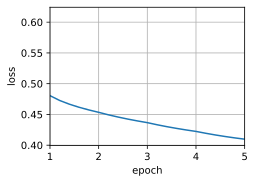

In [ ]:
lr, num_epochs = 0.002, 5
train(net, data_iter, lr, num_epochs)

### 15.4.3. Applying Word Embeddings

After training the word2vec model, we can use the cosine similarity of word vectors from the trained model to find words from the dictionary that are most semantically similar to an input word.

In [ ]:
def get_similar_tokens(query_token, k, embed):
    W = embed.weight.data
    x = W[vocab[query_token]]
    # Compute the cosine similarity. Add 1e-9 for numerical stability
    cos = torch.mv(W, x) / torch.sqrt(torch.sum(W * W, dim=1) *
                                      torch.sum(x * x) + 1e-9)
    topk = torch.topk(cos, k=k+1)[1].cpu().numpy().astype('int32')
    for i in topk[1:]:  # Remove the input words
        print(f'cosine sim={float(cos[i]):.3f}: {vocab.to_tokens(i)}')

get_similar_tokens('chip', 3, net[0])

cosine sim=0.667: mainframes
cosine sim=0.666: microprocessor
cosine sim=0.657: mainframe


### 15.4.4. Summary

* We can train a skip-gram model with negative sampling using embedding layers and the binary cross-entropy loss.

* Applications of word embeddings include finding semantically similar words for a given word based on the cosine similarity of word vectors.

### 15.4.5. Exercises

1. Using the trained model, find semantically similar words for other input words. Can you improve the results by tuning hyperparameters?

1. When a training corpus is huge, we often sample context words and noise words for the center words in the current minibatch *when updating model parameters*. In other words, the same center word may have different context words or noise words in different training epochs. What are the benefits of this method? Try to implement this training method.

## 15.5. Word Embedding with Global Vectors (GloVe)

Word-word co-occurrences within context windows may carry rich semantic information. For example, in a large corpus word “solid” is more likely to co-occur with “ice” than “steam”, but word “gas” probably co-occurs with “steam” more frequently than “ice”. Besides, global corpus statistics of such co-occurrences can be precomputed: this can lead to more efficient training. To leverage statistical information in the entire corpus for word embedding, let’s first revisit the skip-gram model in Section 15.1.3, but interpreting it using global corpus statistics such as co-occurrence counts.

### 15.5.1. Skip-Gram with Global Corpus Statistics

Denoting by $q_{ij}$ the conditional probability $P(w_j\mid w_i)$ of word $w_j$ given word $w_i$ in the skip-gram model, we have

$$q_{ij}=\frac{\exp(\mathbf{u}_j^\top \mathbf{v}_i)}{ \sum_{k \in \mathcal{V}} \exp(\mathbf{u}_k^\top \mathbf{v}_i)}, \tag{15.5.1}$$

where for any index $i$ vectors $\mathbf{v}_i$ and $\mathbf{u}_i$ represent word $w_i$ as the center word and context word, respectively, and $\mathcal{V} = \{0, 1, \ldots, |\mathcal{V}|-1\}$ is the index set of the vocabulary.

Consider word $w_i$ that may occur multiple times in the corpus. In the entire corpus, all the context words wherever $w_i$ is taken as their center word form a *multiset* $\mathcal{C}_i$ of word indices that *allows for multiple instances of the same element*. For any element, its number of instances is called its **multiplicity**. To illustrate with an example, suppose that word $w_i$ occurs twice in the corpus and indices of the context words that take $w_i$ as their center word in the two context windows are $k, j, m, k$ and $k, l, k, j$. Thus, multiset $\mathcal{C}_i = \{j, j, k, k, k, k, l, m\}$, where multiplicities of elements $j, k, l, m$ are 2, 4, 1, 1, respectively.

Now let's denote the multiplicity of element $j$ in multiset $\mathcal{C}_i$ as $x_{ij}$. This is the global co-occurrence count of word $w_j$ (as the context word) and word $w_i$ (as the center word) in the same context window in the entire corpus. Using such global corpus statistics, the loss function of the skip-gram model is equivalent to

$$-\sum_{i\in\mathcal{V}}\sum_{j\in\mathcal{V}} x_{ij} \log\,q_{ij}. \tag{15.5.2}$$

We further denote by $x_i$ the number of all the context words in the context windows where $w_i$ occurs as their center word, which is equivalent to $|\mathcal{C}_i|$. Letting $p_{ij}$ be the conditional probability $x_{ij}/x_i$ for generating context word $w_j$ given center word $w_i$, (15.5.2) can be rewritten as

$$-\sum_{i\in\mathcal{V}} x_i \sum_{j\in\mathcal{V}} p_{ij} \log\,q_{ij}. \tag{15.5.3}$$

In (15.5.3), $-\sum_{j\in\mathcal{V}} p_{ij} \log\,q_{ij}$ calculates the cross-entropy of the conditional distribution $p_{ij}$ of global corpus statistics and the conditional distribution $q_{ij}$ of model predictions. This loss is also weighted by $x_i$ as explained above. Minimizing the loss function in (15.5.3) will allow the predicted conditional distribution to get close to the conditional distribution from the global corpus statistics.

Though being commonly used for measuring the distance between probability distributions, the cross-entropy loss function may not be a good choice here. On the one hand, as we mentioned in Section 15.2, the cost of properly normalizing $q_{ij}$ results in the sum over the entire vocabulary, which can be computationally expensive. On the other hand, a large number of rare events from a large corpus are often modeled by the cross-entropy loss to be assigned with too much weight.

---
通义：要理解 式 (15.5.2) 这个损失函数的推导过程，我们首先要回顾 skip-gram 模型的基本目标，即通过最大化给定中心词预测其上下文词的概率来学习高质量的词嵌入。在数学上，这意味着我们要最大化整个语料库中所有中心词-上下文词对的对数似然性。

为了更实际地利用数据并进行有效的计算，我们转向使用全局共现计数 $x_{ij}$，即词 $j$ 作为上下文词与中心词 $i$ 在同一个上下文窗口中共同出现的次数。这引入了多集 $\mathcal{C}_i$ 的概念，其中每个元素（上下文词的索引）的重度即为其对应的共现计数。

将这些共现计数纳入考虑，我们可以将原始的目标函数转换为一个加权求和的形式，其中每个词对的贡献由它们的共现次数决定，从而得到最终的损失函数表达式 (15.5.2)。

---
通义：关于“大量罕见事件”的理解，这里的关键在于“大量”和“罕见”是针对不同维度来说的。在大规模语料库中，尽管每种非常罕见的上下文-中心词组合出现的频率很低，但由于语料库本身的大小庞大，即使是这些罕见组合也可能累积成为总数相当大的事件集合。换句话说，单独来看，某个特定的罕见事件确实不常见，但当我们考虑所有可能的罕见事件组合时，它们作为一个整体对模型训练的影响便不容忽视了。这就意味着，在使用交叉熵作为损失函数时，模型可能会过分关注这些虽个别罕见、但总量不少的事件，导致训练偏向，而忽略了更为普遍的语言模式。因此，需要寻找更高效的策略或调整损失函数来平衡这种现象，确保模型既能有效学习到常见模式，又不至于被罕见事件所主导。

### 15.5.2. The GloVe Model

In view of this, the *GloVe* model makes three changes to the skip-gram model based on squared loss (Pennington et al., 2014):

1. Use variables $p'_{ij}=x_{ij}$ and $q'_{ij}=\exp(\mathbf{u}_j^\top \mathbf{v}_i)$ that are not probability distributions and take the logarithm of both, so the squared loss term is $\left(\log\,p'_{ij} - \log\,q'_{ij}\right)^2 = \left(\mathbf{u}_j^\top \mathbf{v}_i - \log\,x_{ij}\right)^2$.

---
牧之：这个平方损失函数是怎么得出来的？

通义：在 GloVe 模型中，对 skip-gram 模型进行了基于平方损失的改进，采用了非概率分布的变量 $p'_{ij}$ 和 $q'_{ij}$。具体来说：

- $p'_{ij}$ 被定义为实际的共现计数 $x_{ij}$，这反映了在语料库中词 $i$ 和词 $i$ 共现的频次。
- $q'_{ij}$ 则是通过词向量内积 $\mathbf{u}_j^\top \mathbf{v}_i$ 来近似，这对应于通过词嵌入表达的相似度或相关性。

接下来，GloVe 模型通过取对数来处理这两个量，目的是将问题转化为对数空间下的优化，这样做的好处是可以简化计算并且使得梯度更加稳定。

1. Add two scalar model parameters for each word $w_i$: the center word bias $b_i$ and the context word bias $c_i$.

---
牧之：加了两个标量与合并出一个标量有什么区别？为什么要用两个标量？

通义：在 GloVe 模型中，为每个词 $w_i$ 增加两个标量参数——中心词偏置 $b_i$ 和上下文词偏置 $c_i$，这一设计背后的动机是为了解决词频信息和词语搭配的非对称性问题，并提供额外的灵活性以更好地拟合数据。

1. **加了两个标量与合并成一个标量的区别**：如果只使用一个标量参数，那么该参数需要同时考虑词作为中心词和上下文词的情况，可能无法精确地捕捉到词在两种角色下的不同特性或频率效应。换句话说，一个词作为中心词出现的频率特性和它作为上下文词出现的偏好可能是不同的，因此用两个独立的偏置项能够更细致地调整这些差异。合并成单一标量会忽略这种上下文角色的差异性，可能导致模型学习到的词向量不能充分反映实际语言中丰富的上下文依赖关系。

2. **为何要用两个标量**：

  - **区分中心词与上下文词的作用**：中心词和上下文词在文本中的角色和统计性质可能不同。例如，某些词可能更频繁地作为句子的主题（中心词），而另一些词则更多地扮演修饰或补充说明的角色（上下文词）。分开设置偏置项允许模型分别适应这两种情况下的不同统计特性。

  - **提高模型表达能力**：引入额外的参数可以提升模型的自由度，帮助模型更好地拟合训练数据，特别是在处理那些共现频率较低但含有重要语义信息的词语搭配时，上下文词偏置和中心词偏置能为这些稀有事件提供必要的调整，从而提高模型的整体性能。

  - **控制频率效应**：偏置项还可以用来控制高频词和低频词对模型学习的影响，帮助模型在训练过程中减少因频率不均衡导致的偏差，比如中心词偏置可以补偿某些词因为太常见而对预测结果的过度影响。

综上所述，使用两个独立的偏置参数 $b_i$ 和 $c_i$ 是为了更精确地建模词汇在不同上下文位置的出现规律，以及提升模型对语言复杂性的表达能力。

1. Replace the weight of each loss term with the weight function $h(x_{ij})$, where $h(x)$ is increasing in the interval of $[0, 1]$.

---
牧之：为什么要强调 $h(x)$ 是递增的？

通义：强调 $h(x)$ 是区间 $[0,1]$ 内的增函数，主要出于以下几个原因：

- **控制损失贡献**：$h(x_{ij})$ 作为损失项的权重函数，其递增性质意味着随着共现计数 $x_{ij}$ 的增加，相应词对 $(w_i,w_j)$ 对总损失函数的贡献也会增大。这种设计有利于模型更关注那些共现频率较高的词对，因为这些词对往往携带了更强烈和稳定的语义关联信息。递增的 $h(x)$ 确保了模型训练时能依据实际数据中的共现频次合理分配学习注意力。

- **平衡频次与信息量**：在自然语言中，高频词对往往包含更多的普遍语言结构信息，而低频词对可能蕴含特定领域或罕见的语言现象。通过使用递增的权重函数，GloVe 模型能够在优化过程中适当放大高频词对的影响力，同时保证所有词对都能根据其出现频次的实际情况对模型学习有所贡献，实现对语言共现模式的全面捕捉。

- **避免过拟合**：在自然语言处理中，低频词对往往更容易受到噪声数据的影响。若直接按照共现频次进行加权，可能会过分强调这些噪声较大的样本，导致模型过拟合。通过选用一个递增且在合理区间内的权重函数，可以在一定程度上平衡频次与噪声的关系，避免模型对极少数异常样本过度敏感，从而促进泛化能力。

- **灵活调整学习重点**：递增函数的设计为模型提供了调节学习重点的灵活性。例如，若想更重视那些频繁出现的重要共现模式，可以选择增长速率较快的函数；反之，如果希望模型也能很好地学习低频但重要的语言结构，则可选择增长速率较为平缓的函数。这样，通过调整 $h(x)$ 的具体形式，可以在不同应用场景中找到最适合的平衡点。

综上所述，$h(x)$ 的递增性质是 GloVe 模型设计中的一项关键策略，旨在合理指导模型学习过程中对不同共现频率词对的关注程度，以期达到高效且稳健的语言表示学习效果。

Putting all things together, training GloVe is to minimize the following loss function:

$$\sum_{i\in\mathcal{V}} \sum_{j\in\mathcal{V}} h(x_{ij}) \left(\mathbf{u}_j^\top \mathbf{v}_i + b_i + c_j - \log\,x_{ij}\right)^2. \tag{15.5.4}$$

For the weight function, a suggested choice is: $h(x) = (x/c) ^\alpha$ (e.g $\alpha = 0.75$) if $x < c$ (e.g., $c = 100$); otherwise $h(x) = 1$. In this case, because $h(0)=0$, the squared loss term for any $x_{ij}=0$ can be omitted for computational efficiency. For example, when using minibatch stochastic gradient descent for training, at each iteration we randomly sample a minibatch of *non-zero* $x_{ij}$ to calculate gradients and update the model parameters. Note that these non-zero $x_{ij}$ are precomputed global corpus statistics; thus, the model is called GloVe for *Global Vectors*.

It should be emphasized that if word $w_i$ appears in the context window of word $w_j$, then *vice versa*. Therefore, $x_{ij}=x_{ji}$. Unlike word2vec that fits the asymmetric conditional probability $p_{ij}$, GloVe fits the symmetric $\log \, x_{ij}$. Therefore, the center word vector and the context word vector of any word are mathematically equivalent in the GloVe model. However in practice, owing to different initialization values, the same word may still get different values in these two vectors after training: GloVe sums them up as the output vector.

---
牧之：应该如何理解这段话？

通义：这段话可以从几个关键点来理解：

1. **对称性**：在自然语言文本中，如果词 $w_i$ 出现在词 $w_j$ 的上下文窗口中，根据上下文的定义，同样地，词 $w_j$ 也会出现在词 $w_i$ 的上下文窗口里。这意味着对于任何一对词 $(w_i, w_j)$，它们的共现次数是相互对称的，即 $x_{ij}=x_{ji}$。这种对称性体现了词语共现关系的本质，无论以哪个词为中心，二者的相互作用是相同的。

1. **模型差异**：word2vec 模型（特别是 skip-gram 变体）通过优化条件概率 $p_{ij}=P(w_j\mid w_i)$ 来学习词嵌入，这个条件概率是不对称的，意味着模型看待词 $i$ 作为中心词时，词 $j$ 作为上下文的预测，与反过来的情况（词 $j$ 作为中心词，词 $i$ 作为上下文）是不一样的，分别对应中心词向量 $\mathbf{v}_i$ 和上下文词向量 \mathbf{u}_j。

1. **GloVe 的对称处理**：与 word2vec 不同，GloVe 模型直接拟合的是对称的量——对数共现频次 $\log x_{ij}$，这意味着它在数学上不再区分中心词和上下文词，认为一个词作为中心词和作为上下文词的语义贡献是对称等价的。因此，理论上在 GloVe 模型中，一个词的中心词向量 $\mathbf{v}_i$ 和它的上下文词向量 \mathbf{u}_j 应当是数学等价的。

1. **实践中的差异**：虽然理论上相同，但在实际训练过程中，由于初始化不同及优化算法的随机性，即便是对称的设置，同一个词的中心词向量和上下文词向量在训练结束后仍可能会略有差异。GloVe 处理这个问题的方式是简单地将这两个向量相加，作为该词的最终输出向量，这样做既考虑了理论上的对称性，又在实际操作中合并了可能存在的微小差异，力求获得一个更全面的词表示。

综上，GloVe 模型通过对称地考虑词语共现，强调了词之间的相互作用不应受限于上下文中心的视角，而通过合并中心词向量与上下文词向量的做法，尽量保证了模型学习到的词嵌入的一致性和完整性。

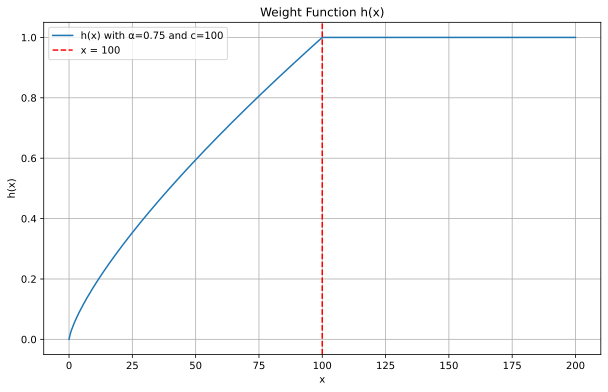

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.75
c = 100

x = np.linspace(0, 200, 400)

y = np.piecewise(x, [x < c, x >= c], [(lambda x: (x/c)**alpha), 1])

plt.figure(figsize=(10, 6))
plt.plot(x, y, label=f'h(x) with α={alpha} and c={c}')
plt.title('Weight Function h(x)')
plt.xlabel('x')
plt.ylabel('h(x)')
plt.axvline(x=c, color='r', linestyle='--', label=f'x = {c}')
plt.legend()
plt.grid(True)
plt.show()

---
牧之：怎么解读这个曲线？我怎么感觉这个曲线没有抑制低频词，而是抑制了高频词的作用？

通义：让我们仔细分析这个权重函数曲线，以正确理解它对不同共现频次词语的影响：

**函数解析**

给定的函数 $h(x) = (x/c) ^\alpha$ 当 $x \lt c$，并且当 $x \ge c$ 时 $h(x)=1$。其中，$\alpha=0.75$ 和 $c=100$ 作为例子。这个设计的目的之一是平衡高频词和低频词的贡献。

- **对于高频词**（$x \ge c$）：当共现频次 $x$ 达到或超过阈值 $c$ 时，权重函数的值固定为 1。这意味着高频词对的损失项权重不再随它们的频率增加而继续增加。这实际上没有“抑制”高频词，而是限制了它们的贡献不会无限增长，给予高频词一个恒定的、重要的但有限的影响力。
- **对于低频词**（$x \lt c$）：在这个区域，函数呈现增长趋势，因为它是 $(x/c) ^\alpha$ 的形式。当 $x$ 增大接近 $c$ 时，$h(x)$ 的值会增加，但增加的速度因为指数 $\alpha \lt 1$ 而较缓。这意味着低频词随着其频率增加，它们在模型学习中的权重也逐渐加大，但增速慢于线性增长，这种设计有助于“提升”而不是“抑制”低频词的贡献，使得模型对低频且可能含有丰富语义信息的词语搭配也有一定的学习机会。

**曲线解读**

在绘图中，你将看到随着 $x$ 值（共现频次）从小到大变化时，$h(x)$ 值开始时增长缓慢，到达 $c=100$ 时突然跃升至 1，然后保持不变。这种形状说明了低频词（尤其是在 $x$ 远小于 $c$ 时）的损失项权重增加较为温和，给予了它们相对较高的关注度，而高频词（$x \ge c$）则被赋予了固定的最大权重，防止它们过度主导模型的学习过程。

**总结**

所以，这个曲线设计的意图并不是要“抑制”高频词，而是通过限制它们的最高权重来平衡高频与低频词的影响力，同时通过让低频词的权重随着其频次适度增加来确保它们在模型训练中也能得到适当的考虑。这有助于模型学习更加广泛且平衡的语言特征。

### 15.5.3. Interpreting GloVe from the Ratio of Co-occurrence Probabilities

We can also interpret the GloVe model from another perspective. Using the same notation in Section 15.5.1, let $p_{ij} \stackrel{\textrm{def}}{=} P(w_j \mid w_i)$ be the conditional probability of generating the context word $w_j$ given $w_i$ as the center word in the corpus. Table 15.5.1 lists several co-occurrence probabilities given words "ice" and "steam" and their ratios based on statistics from a large corpus.

<center>Table 15.5.1: Word-word co-occurrence probabilities and their ratios from a large corpus (adapted from Table 1 in Pennington et al. (2014))</center>

|$w_k$ | solid | gas | water | fashion |
|:--|:-|:-|:-|:-|
| $p_1=P(w_k\mid \textrm{ice})$ |0.00019|0.000066|0.003|0.000017|
| $p_2=P(w_k\mid\textrm{steam})$ |0.000022|0.00078|0.0022|0.000018|
| $p_1/p_2$ |8.9|0.085|1.36|0.96|

We can observe the following from Table 15.5.1:

* For a word $w_k$ that is related to "ice" but unrelated to "steam", such as $w_k=\textrm{solid}$, we expect a larger ratio of co-occurence probabilities, such as 8.9.

* For a word $w_k$ that is related to "steam" but unrelated to "ice", such as $w_k=\textrm{gas}$, we expect a smaller ratio of co-occurence probabilities, such as 0.085.

* For a word $w_k$ that is related to both "ice" and "steam", such as $w_k=\textrm{water}$, we expect a ratio of co-occurence probabilities that is close to 1, such as 1.36.

* For a word $w_k$ that is unrelated to both "ice" and "steam", such as $w_k=\textrm{fashion}$, we expect a ratio of co-occurence probabilities that is close to 1, such as 0.96.

It can be seen that the ratio of co-occurrence probabilities can intuitively express the relationship between words. Thus, we can design a function of three word vectors to fit this ratio. For the ratio of co-occurrence probabilities ${p_{ij}}/{p_{ik}}$ with $w_i$ being the center word and $w_j$ and $w_k$ being the context words, we want to fit this ratio using some function $f$:

$$f(\mathbf{u}_j, \mathbf{u}_k, {\mathbf{v}}_i) \approx \frac{p_{ij}}{p_{ik}}. \tag{15.5.5}$$

Among many possible designs for $f$, we only pick a reasonable choice in the following. Since the ratio of co-occurrence probabilities is a scalar, we require that $f$ be a scalar function, such as $f(\mathbf{u}_j, \mathbf{u}_k, {\mathbf{v}}_i) = f\left((\mathbf{u}_j - \mathbf{u}_k)^\top {\mathbf{v}}_i\right)$. Switching word indices $j$ and $k$ in (15.5.5), it must hold that $f(x)f(-x)=1$, so one possibility is $f(x)=\exp(x)$, i.e.,

$$f(\mathbf{u}_j, \mathbf{u}_k, {\mathbf{v}}_i) = \frac{\exp\left(\mathbf{u}_j^\top {\mathbf{v}}_i\right)}{\exp\left(\mathbf{u}_k^\top {\mathbf{v}}_i\right)} \approx \frac{p_{ij}}{p_{ik}}. \tag{15.5.6}$$

Now let's pick $\exp\left(\mathbf{u}_j^\top {\mathbf{v}}_i\right) \approx \alpha p_{ij}$, where $\alpha$ is a constant. Since $p_{ij}=x_{ij}/x_i$, after taking the logarithm on both sides we get $\mathbf{u}_j^\top {\mathbf{v}}_i \approx \log\,\alpha + \log\,x_{ij} - \log\,x_i$. We may use additional bias terms to fit $- \log\, \alpha + \log\, x_i$, such as the center word bias $b_i$ and the context word bias $c_j$:

$$\mathbf{u}_j^\top \mathbf{v}_i + b_i + c_j \approx \log\, x_{ij}. \tag{15.5.7}$$

Measuring the squared error of (15.5.7) with weights, the GloVe loss function in (15.5.4) is obtained.

### 15.5.4. Summary

* The skip-gram model can be interpreted using global corpus statistics such as word-word co-occurrence counts.

* The cross-entropy loss may not be a good choice for measuring the difference of two probability distributions, especially for a large corpus. GloVe uses squared loss to fit precomputed global corpus statistics.

* The center word vector and the context word vector are mathematically equivalent for any word in GloVe.

* GloVe can be interpreted from the ratio of word-word co-occurrence probabilities.

### 15.5.5. Exercises

1. If words $w_i$ and $w_j$ co-occur in the same context window, how can we use their   distance in the text sequence to redesign the method for  calculating the conditional probability $p_{ij}$? Hint: see Section 4.2 of the GloVe paper (Pennington et al., 2014).

1. For any word, are its center word bias  and context word bias mathematically equivalent in GloVe? Why?

## 15.6. Subword Embedding

In English, words such as “helps”, “helped”, and “helping” are inflected forms of the same word “help”. The relationship between “dog” and “dogs” is the same as that between “cat” and “cats”, and the relationship between “boy” and “boyfriend” is the same as that between “girl” and “girlfriend”. In other languages such as French and Spanish, many verbs have over 40 inflected forms, while in Finnish, a noun may have up to 15 cases. In linguistics, morphology studies word formation and word relationships. However, the internal structure of words was neither explored in word2vec nor in GloVe.

### 15.6.1. The fastText Model

Recall how words are represented in word2vec. In both the skip-gram model and the continuous bag-of-words model, different inflected forms of the same word are directly represented by different vectors without shared parameters. To use morphological information, the *fastText* model proposed a *subword embedding* approach, where a subword is a character $n$-gram (Bojanowski et al., 2017). Instead of learning word-level vector representations, fastText can be considered as the subword-level skip-gram, where each *center word* is represented by the sum of its subword vectors.

Let's illustrate how to obtain subwords for each center word in fastText using the word "where". First, add special characters “&lt;” and “&gt;” at the beginning and end of the word to distinguish prefixes and suffixes from other subwords. Then, extract character $n$-grams from the word. For example, when $n=3$, we obtain all subwords of length 3: "&lt;wh", "whe", "her", "ere", "re&gt;", and the special subword "&lt;where&gt;".

In fastText, for any word $w$, denote by $\mathcal{G}_w$ the union of all its subwords of length between 3 and 6 and its special subword. The vocabulary is the union of the subwords of all words. Letting $\mathbf{z}_g$ be the vector of subword $g$ in the dictionary, the vector $\mathbf{v}_w$ for word $w$ as a center word in the skip-gram model is the sum of its subword vectors:

$$\mathbf{v}_w = \sum_{g\in\mathcal{G}_w} \mathbf{z}_g. \tag{15.6.1}$$

The rest of fastText is the same as the skip-gram model. Compared with the skip-gram model, the vocabulary in fastText is larger, resulting in more model parameters. Besides, to calculate the representation of a word, all its subword vectors have to be summed, leading to higher computational complexity. However, thanks to shared parameters from subwords among words with similar structures, rare words and even out-of-vocabulary words may obtain better vector representations in fastText.

---
牧之：这里为什么说字符长度从 3 到 6？这个 6 是有什么讲究的吗？

通义：在FastText中选择字符 $n$-gram 的长度范围从 3 到 6，主要是基于权衡模型的表达能力与计算效率的一个经验决策。以下是几个可能的原因：

1. **表达能力**: 使用不同长度的 $n$-gram 可以帮助模型捕捉不同层级的形态学（morphology）信息。较短的 $n$-gram（如 3-gram）可以捕捉到词根和常见的词缀信息，而较长的 $n$-gram（如 5 或 6-gram）则能够涵盖更复杂的形态变化或特定的词尾模式，这对于处理形态丰富的语言特别有用。这样，即使是词形变化较多的单词也能通过共享的子词向量得到较好的表示。

1. **计算效率与词汇表大小**: 长度限制在6以内可以控制生成的子词数量在一个可管理的范围内。如果 $n$-gram 的长度设置得太大，会导致子词的组合爆炸性增长，从而极大地增加词汇表的大小和模型参数的数量，进而加重计算负担和内存需求。6 作为一个具体的数值，是在表达能力与计算效率之间做出的一种折衷。

1. **实践验证**: Bojanowski等人在提出 FastText 时，可能基于实验观察发现，3 到 6 的 $n$-gram 长度区间能够在多种任务和数据集上提供较为理想的表现。这通常是一个通过实验调整找到的“最佳实践”数值，它确保了模型在不同场景下的泛化能力与性能。

总之，选择字符 $n$-gram 的长度为 3 到 6 是一个基于模型表达力、效率和实际应用效果的综合考量。在不同的应用场景中，这个范围也可以根据具体需求进行调整。

### 15.6.2. Byte Pair Encoding

In fastText, all the extracted subwords have to be of the specified lengths, such as $3$ to $6$, thus the vocabulary size cannot be predefined. To allow for variable-length subwords in a fixed-size vocabulary, we can apply a compression algorithm called *byte pair encoding* (BPE) to extract subwords (Sennrich et al., 2015).

Byte pair encoding performs a statistical analysis of the training dataset to discover common symbols within a word, such as consecutive characters of arbitrary length. Starting from symbols of length 1, byte pair encoding iteratively merges the most frequent pair of consecutive symbols to produce new longer symbols. Note that for efficiency, pairs crossing word boundaries are not considered. In the end, we can use such symbols as subwords to segment words. Byte pair encoding and its variants has been used for input representations in popular natural language processing pretraining models such as GPT-2 (Radford et al., 2019) and RoBERTa (Liu et al., 2019). In the following, we will illustrate how byte pair encoding works.

First, we initialize the vocabulary of symbols as all the English lowercase characters, a special end-of-word symbol `'_'`, and a special unknown symbol `'[UNK]'`.

---
牧之：能否介绍一下 byte pair encoding？

通义：Byte Pair Encoding（BPE）是一种数据压缩算法，最初设计用于无损的数据压缩，但在自然语言处理领域，它被重新利用来高效地构建词汇表并表示文本中的单词为子词序列。这种方法尤其适用于处理大量词汇或者有形态变化的语言，能够在保留词汇多样性的前提下，有效减少词汇表的大小。下面是 BPE 算法的基本步骤和原理：

**BPE的基本流程**：

1. **初始化**：首先，将每个字符视为一个独立的符号（token），创建一个初始的符号集合。这个集合就是所有单个字符构成的集合。

1. **统计频率**：接下来，对文本数据集进行遍历，统计每一对相邻符号（字符）出现的频次。注意，此时只考虑单词内部的相邻符号对，而不跨单词边界。

1. **合并最频繁对**：在统计出的符号对中，找到出现频率最高的那个对。然后，在符号集中加入一个新的符号，该符号等于这对高频符号的合并结果。例如，如果"th"是最常出现的对，则添加"th"作为一个新符号。

1. **重复步骤**：删除原数据集中所有出现的该高频对，并用新加入的符号替换它们，然后回到步骤 2，再次统计新的符号对的频率。这个过程不断迭代，每次迭代都会合并当前最频繁出现的符号对，直到达到预设的词汇表大小或者满足某种停止条件为止。

1. **编码文本**：完成迭代后，使用最终的符号集合来编码文本。任何未被直接合并过的符号对则保持原样，而那些在迭代过程中被合并的符号则用新符号替代。最终，文本中的每个单词都可以被分解成一串 BPE 符号，即子词。

**BPE的优点**：

- **适应性强**：BPE 能自适应地学习到文本中的常见子结构，特别是对于形态丰富的语言特别有效。

- **词汇表可控**：通过控制迭代次数或目标词汇表大小，可以平衡词汇表的复杂度与模型的实用性。

- **易于理解和实现**：算法直观，实现相对简单，且能够有效减少内存占用，加速模型训练。

**应用示例**：

BPE 在诸如 GPT-2 和 RoBERTa 等大型预训练模型中被广泛应用，作为文本输入的预处理步骤，帮助模型理解和生成词汇量大、形态多变的语言数据，进而提升模型的泛化能力与表达能力。通过将罕见或未知单词分解为已知子词序列，模型可以更好地处理这些词汇，即使它们在训练数据中出现频率不高。

In [ ]:
import collections

symbols = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm',
           'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z',
           '_', '[UNK]']

Since we do not consider symbol pairs that cross boundaries of words, we only need a dictionary `raw_token_freqs` that maps words to their frequencies (number of occurrences) in a dataset. Note that the special symbol `'_'` is appended to each word so that we can easily recover a word sequence (e.g., "a taller man") from a sequence of output symbols ( e.g., "a_ tall er_ man"). Since we start the merging process from a vocabulary of only single characters and special symbols, space is inserted between every pair of consecutive characters within each word (keys of the dictionary `token_freqs`). In other words, space is the delimiter between symbols within a word.

In [ ]:
raw_token_freqs = {'fast_': 4, 'faster_': 3, 'tall_': 5, 'taller_': 4}
token_freqs = {}
for token, freq in raw_token_freqs.items():
    token_freqs[' '.join(list(token))] = raw_token_freqs[token]
token_freqs

{'f a s t _': 4, 'f a s t e r _': 3, 't a l l _': 5, 't a l l e r _': 4}

We define the following `get_max_freq_pair` function that returns the most frequent pair of consecutive symbols within a word, where words come from keys of the input dictionary `token_freqs`.

In [ ]:
def get_max_freq_pair(token_freqs):
    pairs = collections.defaultdict(int)
    for token, freq in token_freqs.items():
        symbols = token.split()
        for i in range(len(symbols) - 1):
            # Key of `pairs` is a tuple of two consecutive symbols
            pairs[symbols[i], symbols[i + 1]] += freq
    return max(pairs, key=pairs.get)  # Key of `pairs` with the max value

As a greedy approach based on frequency of consecutive symbols, byte pair encoding will use the following `merge_symbols` function to merge the most frequent pair of consecutive symbols to produce new symbols.

In [ ]:
def merge_symbols(max_freq_pair, token_freqs, symbols):
    symbols.append(''.join(max_freq_pair))
    new_token_freqs = dict()
    for token, freq in token_freqs.items():
        new_token = token.replace(' '.join(max_freq_pair),
                                  ''.join(max_freq_pair))
        new_token_freqs[new_token] = token_freqs[token]
    return new_token_freqs

Now we iteratively perform the byte pair encoding algorithm over the keys of the dictionary `token_freqs`. In the first iteration, the most frequent pair of consecutive symbols are `'t'` and `'a'`, thus byte pair encoding merges them to produce a new symbol `'ta'`. In the second iteration, byte pair encoding continues to merge `'ta'` and `'l'` to result in another new symbol `'tal'`.

In [ ]:
num_merges = 10
for i in range(num_merges):
    max_freq_pair = get_max_freq_pair(token_freqs)
    token_freqs = merge_symbols(max_freq_pair, token_freqs, symbols)
    print(f'merge #{i + 1}:', max_freq_pair)

merge #1: ('t', 'a')
merge #2: ('ta', 'l')
merge #3: ('tal', 'l')
merge #4: ('f', 'a')
merge #5: ('fa', 's')
merge #6: ('fas', 't')
merge #7: ('e', 'r')
merge #8: ('er', '_')
merge #9: ('tall', '_')
merge #10: ('fast', '_')


After 10 iterations of byte pair encoding, we can see that list `symbols` now contains 10 more symbols that are iteratively merged from other symbols.

In [ ]:
print(symbols)

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '_', '[UNK]', 'ta', 'tal', 'tall', 'fa', 'fas', 'fast', 'er', 'er_', 'tall_', 'fast_']


For the same dataset specified in the keys of the dictionary `raw_token_freqs`, each word in the dataset is now segmented by subwords "fast_", "fast", "er_", "tall_", and "tall" as a result of the byte pair encoding algorithm. For instance, words "faster_" and "taller_" are segmented as "fast er_" and "tall er_", respectively.

In [ ]:
print(list(token_freqs.keys()))

['fast_', 'fast er_', 'tall_', 'tall er_']


Note that the result of byte pair encoding depends on the dataset being used. We can also use the subwords learned from one dataset to segment words of another dataset. As a greedy approach, the following `segment_BPE` function tries to break words into the longest possible subwords from the input argument `symbols`.

In [ ]:
def segment_BPE(tokens, symbols):
    outputs = []
    for token in tokens:
        start, end = 0, len(token)
        cur_output = []
        # Segment token with the longest possible subwords from symbols
        while start < len(token) and start < end:
            if token[start: end] in symbols:
                cur_output.append(token[start: end])
                start = end
                end = len(token)
            else:
                end -= 1
        if start < len(token):
            cur_output.append('[UNK]')
        outputs.append(' '.join(cur_output))
    return outputs

In the following, we use the subwords in list `symbols`, which is learned from the aforementioned dataset, to segment `tokens` that represent another dataset.

In [ ]:
tokens = ['tallest_', 'fatter_']
print(segment_BPE(tokens, symbols))

['tall e s t _', 'fa t t er_']


### 15.6.3. Summary

* The fastText model proposes a subword embedding approach. Based on the skip-gram model in word2vec, it represents a center word as the sum of its subword vectors.

* Byte pair encoding performs a statistical analysis of the training dataset to discover common symbols within a word. As a greedy approach, byte pair encoding iteratively merges the most frequent pair of consecutive symbols.

* Subword embedding may improve the quality of representations of rare words and out-of-dictionary words.

### 15.6.4. Exercises

1. As an example, there are about $3\times 10^8$ possible  $6$-grams in English. What is the issue when there are too many subwords? How to address the issue? Hint: refer to the end of Section 3.2 of the fastText paper (Bojanowski et al., 2017).

1. How to design a subword embedding model based on the continuous bag-of-words model?

1. To get a vocabulary of size $m$, how many merging operations are needed when the initial symbol vocabulary size is $n$?

1. How to extend the idea of byte pair encoding to extract phrases?

## 15.7. Word Similarity and Analogy

In Section 15.4, we trained a word2vec model on a small dataset, and applied it to find semantically similar words for an input word. In practice, word vectors that are pretrained on large corpora can be applied to downstream natural language processing tasks, which will be covered later in Section 16. To demonstrate semantics of pretrained word vectors from large corpora in a straightforward way, let’s apply them in the word similarity and analogy tasks.

In [ ]:
import os
import torch
from torch import nn
from d2l import torch as d2l

### 15.7.1. Loading Pretrained Word Vectors

Below lists pretrained GloVe embeddings of dimension 50, 100, and 300, which can be downloaded from the [GloVe website](https://nlp.stanford.edu/projects/glove/). The pretrained fastText embeddings are available in multiple languages. Here we consider one English version (300-dimensional "wiki.en") that can be downloaded from the [fastText website](https://fasttext.cc/).

In [ ]:
#@ save
d2l.DATA_HUB['glove.6b.50d'] = (d2l.DATA_URL + 'glove.6B.50d.zip',
                                '0b8703943ccdb6eb788e6f091b8946e82231bc4d')

#@ save
d2l.DATA_HUB['glove.6b.100d'] = (d2l.DATA_URL + 'glove.6B.100d.zip',
                                 'cd43bfb07e44e6f27cbcc7bc9ae3d80284fdaf5a')

#@ save
d2l.DATA_HUB['glove.42b.300d'] = (d2l.DATA_URL + 'glove.42B.300d.zip',
                                  'b5116e234e9eb9076672cfeabf5469f3eec904fa')

#@ save
d2l.DATA_HUB['wiki.en'] = (d2l.DATA_URL + 'wiki.en.zip',
                           'c1816da3821ae9f43899be655002f6c723e91b88')

To load these pretrained GloVe and fastText embeddings, we define the following `TokenEmbedding` class.

In [ ]:
#@ save
class TokenEmbedding:
    """Token Embedding."""
    def __init__(self, embedding_name):
        self.idx_to_token, self.idx_to_vec = self._load_embedding(
            embedding_name)
        self.unknown_idx = 0
        self.token_to_idx = {token: idx for idx, token in
                             enumerate(self.idx_to_token)}

    def _load_embedding(self, embedding_name):
        idx_to_token, idx_to_vec = ['<unk>'], []
        data_dir = d2l.download_extract(embedding_name)
        # GloVe website: https://nlp.stanford.edu/projects/glove/
        # fastText website: https://fasttext.cc/
        with open(os.path.join(data_dir, 'vec.txt'), 'r') as f:
            for line in f:
                elems = line.rstrip().split(' ')
                token, elems = elems[0], [float(elem) for elem in elems[1:]]
                # Skip header information, such as the top row in fastText
                if len(elems) > 1:
                    idx_to_token.append(token)
                    idx_to_vec.append(elems)
        idx_to_vec = [[0] * len(idx_to_vec[0])] + idx_to_vec
        return idx_to_token, torch.tensor(idx_to_vec)

    def __getitem__(self, tokens):
        indices = [self.token_to_idx.get(token, self.unknown_idx)
                   for token in tokens]
        vecs = self.idx_to_vec[torch.tensor(indices)]
        return vecs

    def __len__(self):
        return len(self.idx_to_token)

Below we load the 50-dimensional GloVe embeddings (pretrained on a Wikipedia subset). When creating the `TokenEmbedding` instance, the specified embedding file has to be downloaded if it was not yet.

In [ ]:
glove_6b50d = TokenEmbedding('glove.6b.50d')

Output the vocabulary size. The vocabulary contains 400000 words (tokens) and a special unknown token.

In [ ]:
len(glove_6b50d)

400001

We can get the index of a word in the vocabulary, and vice versa.

In [ ]:
glove_6b50d.token_to_idx['beautiful'], glove_6b50d.idx_to_token[3367]

(3367, 'beautiful')

### 15.7.2. Applying Pretrained Word Vectors

Using the loaded GloVe vectors, we will demonstrate their semantics by applying them in the following word similarity and analogy tasks.

#### 15.7.2.1. Word Similarity

Similar to Section 15.4.3, in order to find semantically similar words for an input word based on cosine similarities between word vectors, we implement the following `knn` ($k$-nearest neighbors) function.

In [ ]:
def knn(W, x, k):
    # Add 1e-9 for numerical stability
    cos = torch.mv(W, x.reshape(-1,)) / (
        torch.sqrt(torch.sum(W * W, axis=1) + 1e-9) *
        torch.sqrt((x * x).sum()))
    _, topk = torch.topk(cos, k=k)
    return topk, [cos[int(i)] for i in topk]

Then, we search for similar words using the pretrained word vectors from the `TokenEmbedding` instance embed.

In [ ]:
def get_similar_tokens(query_token, k, embed):
    topk, cos = knn(embed.idx_to_vec, embed[[query_token]], k + 1)
    for i, c in zip(topk[1:], cos[1:]):  # Exclude the input word
        print(f'cosine sim={float(c):.3f}: {embed.idx_to_token[int(i)]}')

The vocabulary of the pretrained word vectors in `glove_6b50d` contains 400000 words and a special unknown token. Excluding the input word and unknown token, among this vocabulary let’s find three most semantically similar words to word “chip”.

In [ ]:
get_similar_tokens('chip', 3, glove_6b50d)

cosine sim=0.856: chips
cosine sim=0.749: intel
cosine sim=0.749: electronics


Below outputs similar words to “baby” and “beautiful”.

In [ ]:
get_similar_tokens('baby', 3, glove_6b50d)

cosine sim=0.839: babies
cosine sim=0.800: boy
cosine sim=0.792: girl


In [ ]:
get_similar_tokens('beautiful', 3, glove_6b50d)

cosine sim=0.921: lovely
cosine sim=0.893: gorgeous
cosine sim=0.830: wonderful


#### 15.7.2.2. Word Analogy

Besides finding similar words, we can also apply word vectors to word analogy tasks. For example, “man”:“woman”::“son”:“daughter” is the form of a word analogy: “man” is to “woman” as “son” is to “daughter”. Specifically, the word analogy completion task can be defined as: for a word analogy $a : b :: c : d$, given the first three words $a$, $b$ and $c$, find $d$. Denote the vector of word $w$ by $\textrm{vec}(w)$. To complete the analogy, we will find the word whose vector is most similar to the result of $\textrm{vec}(c)+\textrm{vec}(b)-\textrm{vec}(a)$.

---
牧之：很神奇，深度讲解一下原理。

通义：词向量在完成词类比任务 (word analogy tasks) 上的应用确实很有趣且高效，它体现了词向量在捕捉语义关系方面的能力。你提到的例子 "man": "woman" :: "son": "daughter" 是一个典型的词对关系，表示 "man" 与 "woman" 之间的关系类似于 "son" 与 "daughter" 之间的关系。这种类比可以被形式化为寻找词向量空间中相似关系的任务。

**原理深入解析**

**向量空间模型**

首先，理解这个词向量方法需要基于“分布式假设” (Distributional Hypothesis)，该假设认为词的含义由它周围的上下文决定。因此，词向量通过学习上下文信息，能够捕获词之间的语义和语法关系。在诸如 Word2Vec、GloVe 等模型训练后，每个词都被映射到了一个高维向量空间中，这个空间里的距离可以反映词义的相似性。

**完成词类比**

在给定的类比问题 $a : b :: c : d$ 中，我们的目标是找到词 $d$，使得 $(d−a)$ 与 $(b−c)$ 之间的关系最相似，或者说 $d$ 的向量 $ \textrm{vec}(d)$ 与向量 $\textrm{vec}(c)+\textrm{vec}(b)-\textrm{vec}(a)$ 最为接近。这个操作背后的直觉是：

- $\textrm{vec}(b)−\textrm{vec}(a)$ 可以视为从词 $a$ 到词 $b$ 的“语义变换向量”，比如在性别上的变化，从男性变为女性。

- 将这个变换应用于 $\textrm{vec}(c)$ 上，即计算 $\textrm{vec}(c)+\textrm{vec}(b)-\textrm{vec}(a)$，理论上应指向一个与 $c$ 有类似语义偏移的新词 $d$，比如从儿子变换到对应于“女儿”的位置。

**计算与搜索**

实际操作中，我们不直接在词汇表中寻找与 $\textrm{vec}(c)+\textrm{vec}(b)-\textrm{vec}(a)$ 完全相等的词向量，而是计算所有词 $\textrm{vec}(w)$ 与这个向量之间的余弦相似度或其他相似度度量，并找出最高分的词作为答案 $d$。这种方法假设了词向量空间中的加减运算能有效捕捉到词汇间的逻辑关系。

**为什么有效**

这一方法之所以有效，是因为高质量的词向量在向量空间中编码了丰富的语义信息。例如，在理想情况下，男性和女性相关的词在向量空间中会有特定的方向性差异，同样，父子、母女等家庭成员关系也有类似的结构。通过向量加减法，我们实际上是利用这种结构化的信息来预测新的关系。

综上所述，利用词向量完成词类比不仅是一种直观且有效的方法，它还展示了词嵌入在探索语言深层结构方面的强大能力。这种方法在实际应用中广泛用于推荐系统、语义搜索和各种自然语言处理任务中。

---
牧之：这是先发现了这个现象，然后来解释这个现象的原理？还是先通过某个原理推导出来可能会有这个应用，然后产生了这个应用？

通义：这个问题很好，实际上，词向量在词类比任务上的应用是一个典型的“先发现现象，后解释原理”的过程。

- **发现现象**： 在早期的研究中，研究人员观察到经过训练的词向量模型（如 Word2Vec、GloVe）能够表现出惊人的特性，即通过简单的向量运算能够揭示出词与词之间的复杂关系。例如，人们偶然发现计算“king”（国王）- "man"（男人）+ "woman"（女人）得到的结果非常接近于"queen"（女王）的向量。这类观察起初可能更多是出于好奇或者数据分析时的意外发现，但它们迅速引起了研究社区的广泛关注。

- **解释原理**： 随着这些现象的发现，研究人员开始深入探讨和理解为何词向量能展现出这样的性质。这涉及到对词嵌入空间特性的理论分析，包括如何通过优化算法（如 skip-gram 或 CBOW）学习到的上下文信息隐含地编码了词语之间的语义和句法关系。特别是，向量空间中的加减操作能够近似地对应于词的关系转移，这被看作是分布式语义表示和线性代数结合的一个美妙巧合。通过数学解释和实验验证，学者们逐渐建立了一套关于为何简单向量运算能够在高维空间中捕获语言规律的理论体系。

因此，词类比任务的应用是先从实践中意外发现的现象出发，随后通过理论研究被深入理解和发展的。这体现了科学研究中常见的“观察-假设-验证”的循环过程，也是自然语言处理领域进展的一个典型例子。

In [ ]:
def get_analogy(token_a, token_b, token_c, embed):
    vecs = embed[[token_a, token_b, token_c]]
    x = vecs[1] - vecs[0] + vecs[2]
    topk, cos = knn(embed.idx_to_vec, x, 1)
    return embed.idx_to_token[int(topk[0])]  # Remove unknown words

Let’s verify the “male-female” analogy using the loaded word vectors.

In [ ]:
get_analogy('man', 'woman', 'son', glove_6b50d)

'daughter'

Below completes a “capital-country” analogy: “beijing”:“china”::“tokyo”:“japan”. This demonstrates semantics in the pretrained word vectors.

In [ ]:
get_analogy('beijing', 'china', 'tokyo', glove_6b50d)

'japan'

For the “adjective-superlative adjective” analogy such as “bad”:“worst”::“big”:“biggest”, we can see that the pretrained word vectors may capture the syntactic information.

In [ ]:
get_analogy('bad', 'worst', 'big', glove_6b50d)

'biggest'

To show the captured notion of past tense in the pretrained word vectors, we can test the syntax using the “present tense-past tense” analogy: “do”:“did”::“go”:“went”.

In [ ]:
get_analogy('do', 'did', 'go', glove_6b50d)

'went'

### 15.7.3. Summary

* In practice, word vectors that are pretrained on large corpora can be applied to downstream natural language processing tasks.

* Pretrained word vectors can be applied to the word similarity and analogy tasks.

### 15.7.4. Exercises

1. Test the fastText results using `TokenEmbedding('wiki.en')`.

1. When the vocabulary is extremely large, how can we find similar words or complete a word analogy faster?

## 15.8. Bidirectional Encoder Representations from Transformers (BERT)

We have introduced several word embedding models for natural language understanding. After pretraining, the output can be thought of as a matrix where each row is a vector that represents a word of a predefined vocabulary. In fact, these word embedding models are all *context-independent*. Let's begin by illustrating this property.

### 15.8.1. From Context-Independent to Context-Sensitive

Recall the experiments in Section 15.4 and Section 15.7. For instance, word2vec and GloVe both assign the same pretrained vector to the same word regardless of the context of the word (if any). Formally, a context-independent representation of any token $x$ is a function $f(x)$ that only takes $x$ as its input. Given the abundance of polysemy and complex semantics in natural languages, context-independent representations have obvious limitations. For instance, the word "crane" in contexts "a crane is flying" and "a crane driver came" has completely different meanings; thus, the same word may be assigned different representations depending on contexts.

This motivates the development of *context-sensitive* word representations, where representations of words depend on their contexts. Hence, a context-sensitive representation of token $x$ is a function $f(x, c(x))$ depending on both $x$ and its context $c(x)$. Popular context-sensitive representations include TagLM (language-model-augmented sequence tagger) (Peters et al., 2017), CoVe (Context Vectors) (McCann et al., 2017), and ELMo (Embeddings from Language Models) (Peters et al., 2018).

For example, by taking the entire sequence as input, ELMo is a function that assigns a representation to each word from the input sequence. Specifically, ELMo combines all the intermediate layer representations from pretrained bidirectional LSTM as the output representation. Then the ELMo representation will be added to a downstream task's existing supervised model as additional features, such as by concatenating ELMo representation and the original representation (e.g., GloVe) of tokens in the existing model. On the one hand, all the weights in the pretrained bidirectional LSTM model are frozen after ELMo representations are added. On the other hand, the existing supervised model is specifically customized for a given task. Leveraging different best models for different tasks at that time, adding ELMo improved the state of the art across six natural language processing tasks: sentiment analysis, natural language inference, semantic role labeling, coreference resolution, named entity recognition, and question answering.

---
牧之：我不太理解如何做到上下文相关的，如果要上下文相关，意味着要能处理序列，那岂不是要在表征中带着一个网络模型？

通义：您的理解是正确的。上下文相关的词表示方法，如 ELMo，确实通过在词表征中融入网络模型（尤其是深度学习模型如 LSTM）来捕捉序列中的上下文信息。以下是更详细的解释：

**如何实现上下文相关性**

1. **模型架构**：以 ELMo 为例，它基于双向 LSTM（长短期记忆网络）模型。双向 LSTM 能够同时从前向后以及从后向前读取输入序列，这意味着每个词不仅基于它之前的上下文（前向 LSTM），还基于它之后的上下文（后向 LSTM）获得表征。这样，单个词的表征就能综合考虑其在整个句子中的位置和上下文，实现上下文敏感。

1. **多层表征**：ELMo 不仅仅使用 LSTM 的一个隐藏层，而是利用所有隐藏层的输出来生成最终的词表征。每一层的隐藏状态捕捉了不同粒度的语言特征，低层可能偏向于语法信息，而高层可能关注更多的语义信息。通过加权求和这些层的输出，ELMo 能综合多种上下文信息，形成更为丰富、复杂的词表征。

1. **预训练与微调**：ELMo 模型首先在一个大规模无标注文本数据集上进行预训练，学习通用的语言模型任务，这一步骤让模型学习到了丰富的语言上下文知识。然后，当将 ELMo 应用到特定的下游任务（如情感分析、命名实体识别等）时，虽然 LSTM 的权重保持不变（冻结），但 ELMo 的表征会作为一个额外的特征层，整合进下游任务的模型中，有时通过简单的拼接原有特征（如 GloVe）实现。这样，下游模型会根据任务需求对ELMo提供的上下文敏感的词表示进行微调，从而在特定任务上获得更好的性能。

因此，上下文相关的词表征确实是在表征过程中内嵌了神经网络模型，这个模型负责捕获和编码上下文信息，使得每一个词的表征都能体现其在句子中的具体语境，进而增强模型的理解能力。

### 15.8.2. From Task-Specific to Task-Agnostic

Although ELMo has significantly improved solutions to a diverse set of natural language processing tasks, each solution still hinges on a *task-specific* architecture. However, it is practically non-trivial to craft a specific architecture for every natural language processing task. The GPT (Generative Pre-Training) model represents an effort in designing a general *task-agnostic* model for context-sensitive representations (Radford et al., 2018). Built on a Transformer decoder, GPT pretrains a language model that will be used to represent text sequences. When applying GPT to a downstream task, the output of the language model will be fed into an added linear output layer to predict the label of the task. In sharp contrast to ELMo that freezes parameters of the pretrained model, GPT fine-tunes *all* the parameters in the pretrained Transformer decoder during supervised learning of the downstream task. GPT was evaluated on twelve tasks of natural language inference, question answering, sentence similarity, and classification, and improved the state of the art in nine of them with minimal changes to the model architecture.

However, due to the autoregressive nature of language models, GPT only looks forward (left-to-right). In contexts "i went to the bank to deposit cash" and "i went to the bank to sit down", as "bank" is sensitive to the context to its left, GPT will return the same representation for "bank", though it has different meanings.

---
牧之：GPT 预测任务标签，是指 GPT 会自己预测任务类型吗？如果是的话，那这个任务标签，可以是多个任务标签吗？我想应该会有一些任务是多种任务类型混合的吧？

通义：GPT 模型本身并不直接“预测任务标签”来判断任务类型。你的理解可能有稍微的偏差。GPT（以及其后续的版本如 GPT-2、GPT-3 等）是一个生成式预训练模型，它的核心是学习语言的上下文表示。在预训练阶段，GPT 通过学习大量文本数据来预测给定词语或词组在一个句子中的下一个部分是什么，从而获得对语言的深刻理解。这种预训练过程使得模型能够捕获丰富的语言结构和语境信息。

当我们将 GPT 应用于下游任务时，比如情感分析、命名实体识别、问答系统等，我们并不会让 GPT 去“预测这是哪种任务”。相反，我们会根据具体任务的需求，对 GPT 进行微调（fine-tuning）。这意味着在 GPT 模型的顶部添加一个或多个任务特定的输出层，这些输出层的设计依据于任务的目标。例如，如果是做文本分类（比如情感分析），我们可能会添加一个 softmax 层来预测类别概率；如果是做序列标注（比如命名实体识别），则可能添加一个 CRF（条件随机场）层或者直接输出每个位置的标记类别。

至于你提到的“混合任务类型”，确实存在一些自然语言处理任务可能涉及多任务学习（Multi-task Learning），即一个模型同时学习解决多个相关任务。在这种情况下，GPT 或其他类似的预训练模型可以通过共享一部分网络层（通常是底层的 Transformer 层），并在顶部为每个任务设计单独的输出层，从而实现对多个任务的同时学习和预测。这样，模型可以在学习不同任务之间的共通性和差异性中受益，有时候能提升整体的性能。

总结来说，GPT 不是直接预测任务标签，而是通过针对不同任务的微调来适应并解决具体任务，包括那些可能混合了多个任务目标的情况。

### 15.8.3. BERT: Combining the Best of Both Worlds

As we have seen, ELMo encodes context bidirectionally but uses task-specific architectures; while GPT is task-agnostic but encodes context left-to-right. Combining the best of both worlds, BERT (Bidirectional Encoder Representations from Transformers) encodes context bidirectionally and requires minimal architecture changes for a wide range of natural language processing tasks (Devlin et al., 2018). Using a pretrained Transformer encoder, BERT is able to represent any token based on its bidirectional context. During supervised learning of downstream tasks, BERT is similar to GPT in two aspects. First, BERT representations will be fed into an added output layer, with minimal changes to the model architecture depending on nature of tasks, such as predicting for every token vs. predicting for the entire sequence. Second, all the parameters of the pretrained Transformer encoder are fine-tuned, while the additional output layer will be trained from scratch. Fig. 15.8.1 depicts the differences among ELMo, GPT, and BERT.

![](https://d2l.ai/_images/elmo-gpt-bert.svg)
<center>Fig. 15.8.1 A comparison of ELMo, GPT, and BERT.</center>

BERT further improved the state of the art on eleven natural language processing tasks under broad categories of (i) single text classification (e.g., sentiment analysis), (ii) text pair classification (e.g., natural language inference), (iii) question answering, (iv) text tagging (e.g., named entity recognition). All proposed in 2018, from context-sensitive ELMo to task-agnostic GPT and BERT, conceptually simple yet empirically powerful pretraining of deep representations for natural languages have revolutionized solutions to various natural language processing tasks.

In the rest of this chapter, we will dive into the pretraining of BERT. When natural language processing applications are explained in Section 16, we will illustrate fine-tuning of BERT for downstream applications.

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

### 15.8.4. Input Representation

In natural language processing, some tasks (e.g., sentiment analysis) take single text as input, while in some other tasks (e.g., natural language inference), the input is a pair of text sequences. The BERT input sequence unambiguously represents both single text and text pairs. In the former, the BERT input sequence is the concatenation of the special classification token “&lt;cls&gt;”, tokens of a text sequence, and the special separation token “&lt;sep&gt;”. In the latter, the BERT input sequence is the concatenation of “&lt;cls&gt;”, tokens of the first text sequence, “&lt;sep&gt;”, tokens of the second text sequence, and “&lt;sep&gt;”. We will consistently distinguish the terminology "BERT input sequence" from other types of "sequences". For instance, one *BERT input sequence* may include either one *text sequence* or two *text sequences*.

To distinguish text pairs, the learned segment embeddings $\mathbf{e}_A$ and $\mathbf{e}_B$ are added to the token embeddings of the first sequence and the second sequence, respectively. For single text inputs, only $\mathbf{e}_A$ is used.

The following `get_tokens_and_segments` takes either one sentence or two sentences as input, then returns tokens of the BERT input sequence and their corresponding segment IDs.

In [2]:
#@ save
def get_tokens_and_segments(tokens_a, tokens_b=None):
    """Get tokens of the BERT input sequence and their segment IDs."""
    tokens = ['<cls>'] + tokens_a + ['<sep>']
    # 0 and 1 are marking segment A and B, respectively
    segments = [0] * (len(tokens_a) + 2)
    if tokens_b is not None:
        tokens += tokens_b + ['<sep>']
        segments += [1] * (len(tokens_b) + 1)
    return tokens, segments

BERT chooses the Transformer encoder as its bidirectional architecture. Common in the Transformer encoder, positional embeddings are added at every position of the BERT input sequence. However, different from the original Transformer encoder, BERT uses *learnable* positional embeddings. To sum up, Fig. 15.8.2 shows that the embeddings of the BERT input sequence are the sum of the token embeddings, segment embeddings, and positional embeddings.

![](https://d2l.ai/_images/bert-input.svg)
<center>Fig. 15.8.2 The embeddings of the BERT input sequence are the sum of the token embeddings, segment embeddings, and positional embeddings.</center>

The following `BERTEncoder` class is similar to the `TransformerEncoder` class as implemented in Section 11.7. Different from `TransformerEncoder`, `BERTEncoder` uses segment embeddings and learnable positional embeddings.

In [3]:
#@ save
class BERTEncoder(nn.Module):
    """BERT encoder."""
    def __init__(self, vocab_size, num_hiddens, ffn_num_hiddens, num_heads,
                 num_blks, dropout, max_len=1000, **kwargs):
        super(BERTEncoder, self).__init__(**kwargs)
        self.token_embedding = nn.Embedding(vocab_size, num_hiddens)
        self.segment_embedding = nn.Embedding(2, num_hiddens)
        self.blks = nn.Sequential()
        for i in range(num_blks):
            self.blks.add_module(f"{i}", d2l.TransformerEncoderBlock(
                num_hiddens, ffn_num_hiddens, num_heads, dropout, True))
        # In BERT, positional embeddings are learnable, thus we create a
        # parameter of positional embeddings that are long enough
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len,
                                                      num_hiddens))

    def forward(self, tokens, segments, valid_lens):
        # Shape of `X` remains unchanged in the following code snippet:
        # (batch size, max sequence length, `num_hiddens`)
        X = self.token_embedding(tokens) + self.segment_embedding(segments)
        X = X + self.pos_embedding[:, :X.shape[1], :]
        for blk in self.blks:
            X = blk(X, valid_lens)
        return X

Suppose that the vocabulary size is 10000. To demonstrate forward inference of `BERTEncoder`, let’s create an instance of it and initialize its parameters.

In [4]:
vocab_size, num_hiddens, ffn_num_hiddens, num_heads = 10000, 768, 1024, 4
ffn_num_input, num_blks, dropout = 768, 2, 0.2
encoder = BERTEncoder(vocab_size, num_hiddens, ffn_num_hiddens, num_heads,
                      num_blks, dropout)

/home/lancer/miniforge3/envs/d2l/lib/python3.9/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


We define `tokens` to be 2 BERT input sequences of length 8, where each token is an index of the vocabulary. The forward inference of `BERTEncoder` with the input `tokens` returns the encoded result where each token is represented by a vector whose length is predefined by the hyperparameter `num_hiddens`. This hyperparameter is usually referred to as the *hidden size* (number of hidden units) of the Transformer encoder.

In [5]:
tokens = torch.randint(0, vocab_size, (2, 8))
segments = torch.tensor([[0, 0, 0, 0, 1, 1, 1, 1], [0, 0, 0, 1, 1, 1, 1, 1]])
encoded_X = encoder(tokens, segments, None)
encoded_X.shape

torch.Size([2, 8, 768])